# Finance Lag Models Comparison

Single notebook for the linear lag model, GAM, VAR, and their comparison.
All figures use the committed Yahoo Finance snapshot `data/gam_var_finance_exercise_prices.csv`.

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import torch

torch.set_default_dtype(torch.float64)
torch.set_printoptions(precision=4, sci_mode=False)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Config
DATA_PATH = Path("data/gam_var_finance_exercise_prices.csv")
if not DATA_PATH.exists():
    candidates = (
        Path("notebooks/02_interpretable_models") / DATA_PATH,
        Path("exercises/session01") / DATA_PATH,
    )
    for candidate in candidates:
        if candidate.exists():
            DATA_PATH = candidate
            break

STOCK, MKT = "stock", "mkt"
STOCK_TICKER = "AMZN"
MKT_PROXY_NAME = "equal-weight tech basket"
MKT_PROXY_PLOT_LABEL = "Tech basket"
MKT_PROXY_MEMBERS = ("GOOG", "AAPL", "FB", "NFLX", "MSFT")
LAG = 2
N_TEST = 12
GAM_N_SPLINES = 6
LAMBDA = 1.0
EXAMPLE_STEP = 3

FEATURE_LABELS = (
    r"$r_{t-1}^{\mathrm{stock}}$",
    r"$r_{t-2}^{\mathrm{stock}}$",
    r"$r_{t-1}^{\mathrm{mkt}}$",
    r"$r_{t-2}^{\mathrm{mkt}}$",
)
MODEL_COLORS = {
    "Observed": "0.35",
    "Linear lag model": "tab:orange",
    "GAM": "tab:blue",
    "VAR": "tab:cyan",
}
SERIES_LABELS = {STOCK: STOCK_TICKER, MKT: MKT_PROXY_PLOT_LABEL}
OUT_DIR = Path("out") / "finance_lag_model_graphics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected the committed Yahoo Finance snapshot at {DATA_PATH}")

prices = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date").sort_index()[[STOCK, MKT]]
prices_t = torch.as_tensor(prices.to_numpy(), dtype=torch.float64, device=DEVICE)
return_dates = prices.index[1:]

print(
    "Yahoo Finance snapshot:",
    f"stock={STOCK_TICKER}",
    f"| mkt proxy={MKT_PROXY_NAME} built from {', '.join(MKT_PROXY_MEMBERS)}",
)
print("rows:", len(prices))
print("date range:", prices.index.min().date(), "to", prices.index.max().date())
print("torch device:", prices_t.device)

Yahoo Finance snapshot: stock=AMZN | mkt proxy=equal-weight tech basket built from GOOG, AAPL, FB, NFLX, MSFT
rows: 105
date range: 2018-01-01 to 2019-12-30
torch device: cpu


## Shared Plot Style

The style is deliberately plain: white background, normal axes, gray context, orange observed test prices, blue GAM, and cyan VAR.

In [2]:
plt.style.use("classic")
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("config", "InlineBackend.figure_format = 'retina'")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.bbox": "tight",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8.5,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.top": False,
        "ytick.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.grid": True,
        "grid.color": "0.88",
        "grid.linewidth": 0.8,
        "grid.alpha": 1.0,
        "figure.dpi": 140,
        "savefig.dpi": 400,
        "lines.linewidth": 2.0,
        "lines.markeredgewidth": 0.0,
        "scatter.edgecolors": "none",
        "patch.edgecolor": "none",
    }
)

FIGSIZE = (8.0, 4.5)
PANEL_FIGSIZE = (8.0, 5.4)
WIDE_FIGSIZE = (10.0, 4.2)


def save_plot(fig: plt.Figure, name: str) -> tuple[Path, Path]:
    pdf_path = OUT_DIR / f"{name}.pdf"
    png_path = OUT_DIR / f"{name}.png"
    fig.savefig(pdf_path)
    fig.savefig(png_path, dpi=400)
    print(f"saved: {pdf_path}")
    print(f"saved: {png_path}")
    return pdf_path, png_path


def format_dates(ax: plt.Axes, *, maxticks: int = 6) -> None:
    locator = mdates.AutoDateLocator(minticks=3, maxticks=maxticks)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))


def add_test_boundary(ax: plt.Axes, first_test_date) -> None:
    ax.axvline(first_test_date, color="0.55", linestyle=":", linewidth=1.2)

## Data Overview

,stock,mkt
date,,
2018-01-01,1.000000,1.000000
2018-01-08,1.061881,1.053526
2018-01-15,1.053240,1.049860
2018-01-22,1.140676,1.307681
2018-01-29,1.163374,1.273537


saved: out/finance_lag_model_graphics/01_dataset_price_indices.pdf
saved: out/finance_lag_model_graphics/01_dataset_price_indices.png


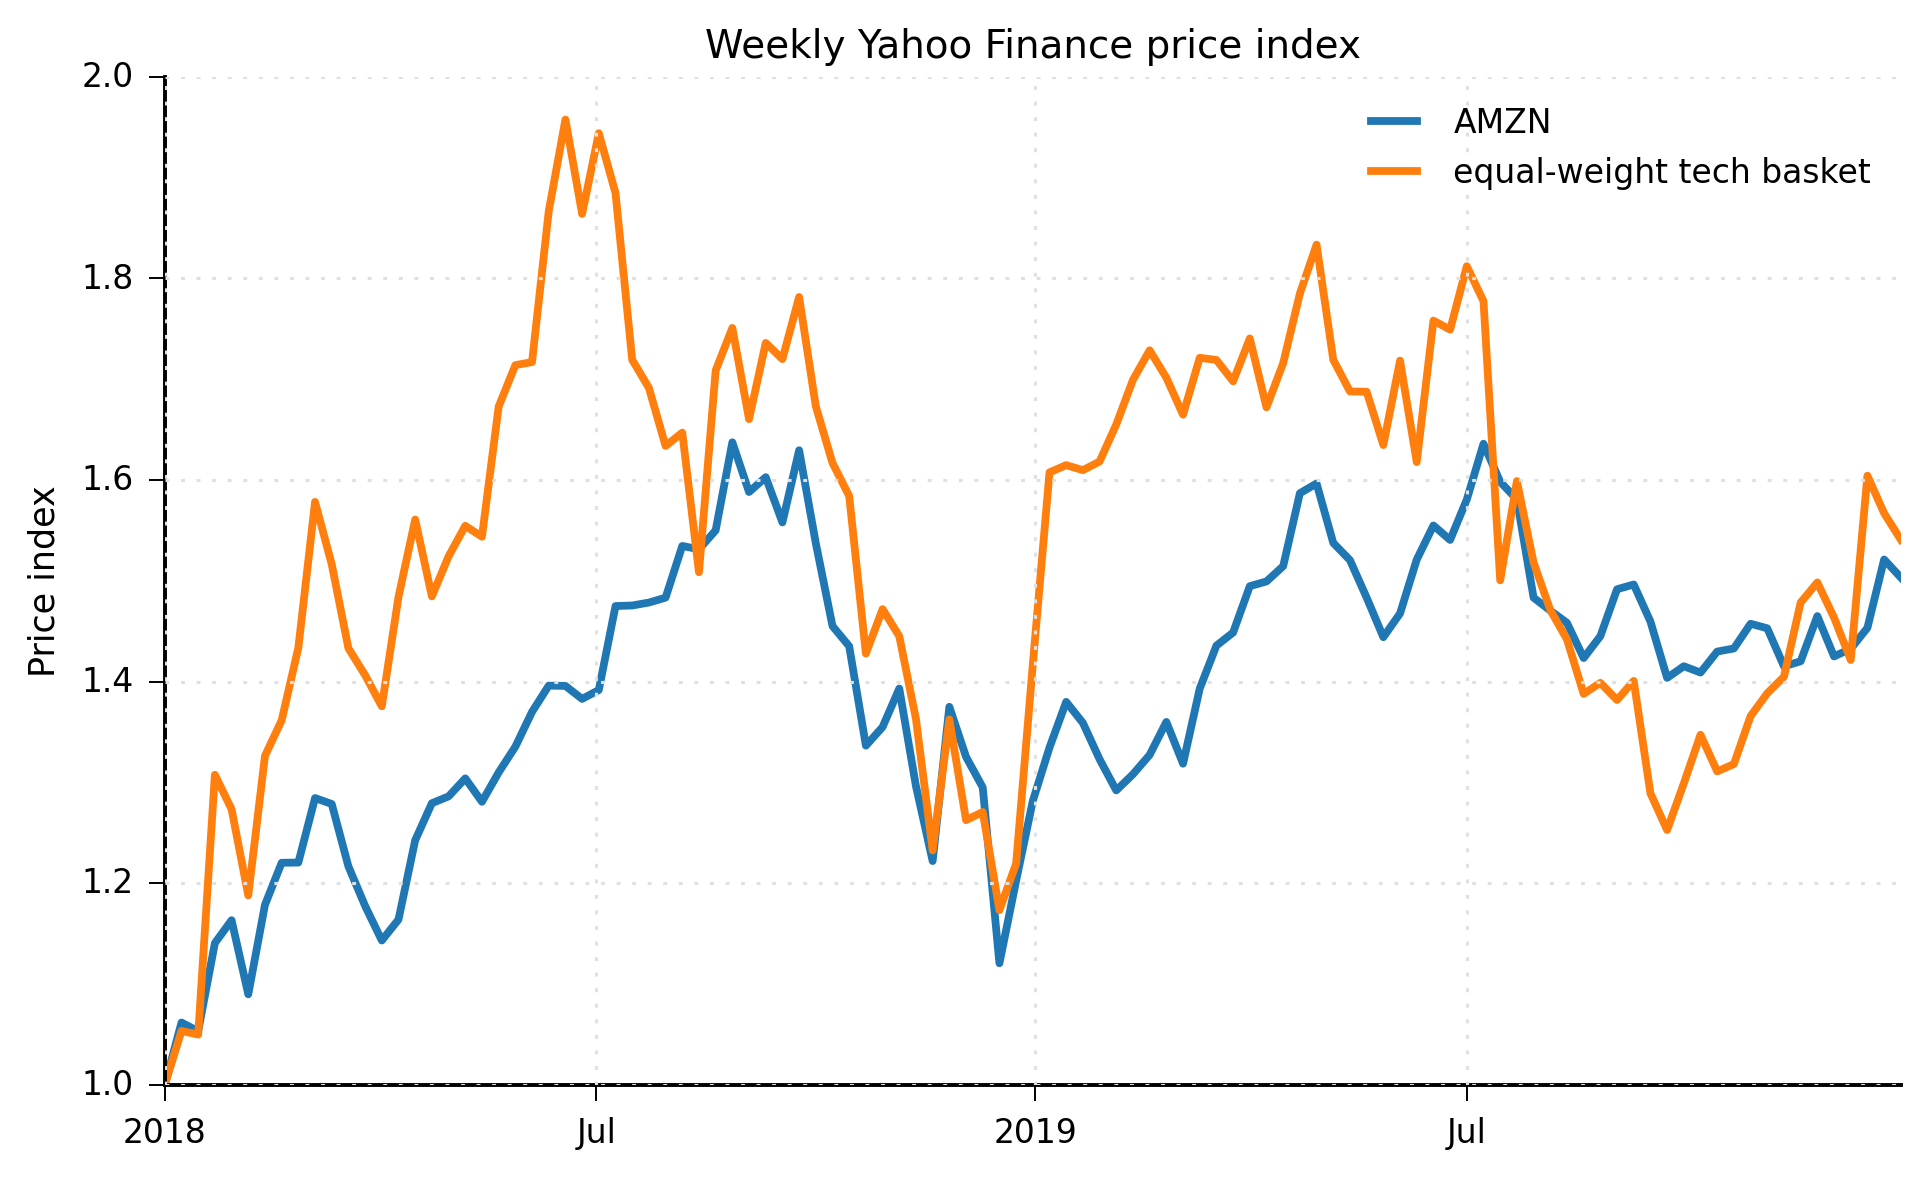

In [3]:
display(prices.head())

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(prices.index, prices[STOCK], color="tab:blue", label=STOCK_TICKER)
ax.plot(prices.index, prices[MKT], color="tab:orange", label=MKT_PROXY_NAME)
ax.set_title("Weekly Yahoo Finance price index")
ax.set_ylabel("Price index")
ax.legend(frameon=False)
format_dates(ax)
save_plot(fig, "01_dataset_price_indices")
plt.show()

## Data Helpers

In [4]:
def add_intercept_column(features: torch.Tensor) -> torch.Tensor:
    '''Add a leading column of ones to a 2-D feature matrix.'''
    features = torch.as_tensor(features, dtype=torch.float64, device=DEVICE)
    if features.ndim == 1:
        features = features[:, None]
    if features.ndim != 2:
        raise ValueError("features must be a 1-D or 2-D tensor")
    ones = torch.ones(features.shape[0], 1, dtype=features.dtype, device=features.device)
    return torch.cat([ones, features], dim=1)


def returns_to_price_path(last_price: float, returns: torch.Tensor) -> torch.Tensor:
    '''Convert predicted log returns into a price path starting after last_price.'''
    return float(last_price) * torch.exp(returns.cumsum(0))


def returns_to_price_frame(last_prices: pd.Series, returns: torch.Tensor, index, columns) -> pd.DataFrame:
    last = torch.as_tensor(last_prices.to_numpy(), dtype=torch.float64, device=DEVICE)
    values = last[None, :] * torch.exp(returns.cumsum(0))
    return pd.DataFrame(values.detach().cpu().numpy(), index=index, columns=columns)


def rmse_basis_points(actual: torch.Tensor, predicted: torch.Tensor) -> float:
    '''Root mean squared error for returns, reported in basis points.'''
    return float(torch.sqrt(torch.mean((actual - predicted) ** 2)) * 1e4)


def mape_percent(actual: pd.Series, predicted: pd.Series) -> float:
    return float(((actual - predicted).abs() / actual.abs()).mean() * 100)


def to_named_series(values: torch.Tensor, index, name: str) -> pd.Series:
    '''Convert a tensor into a named pandas Series with the supplied index.'''
    return pd.Series(values.detach().cpu().numpy(), index=index, name=name)


def assert_close(yours, target, name: str = "result", atol: float = 1e-6, rtol: float = 1e-6):
    y = torch.as_tensor(yours, dtype=torch.float64).detach().cpu()
    t = torch.as_tensor(target, dtype=torch.float64).detach().cpu()
    if y.shape != t.shape:
        raise AssertionError(f"{name}: expected shape {tuple(t.shape)}, got {tuple(y.shape)}")
    if not torch.allclose(y, t, atol=atol, rtol=rtol):
        raise AssertionError(f"{name}: expected {t}, got {y}")


def safe_check(check_fn):
    try:
        check_fn()
        print("Check passed.")
    except NotImplementedError:
        print("TODO - fill in the function above.")
    except AssertionError as e:
        print(f"Check failed:\n{e}")
    except Exception as e:
        print(f"Error while running the check: {type(e).__name__}: {e}")


def compute_log_returns(price_frame: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        torch.log(torch.as_tensor(price_frame.to_numpy(), dtype=torch.float64, device=DEVICE))
        .diff(dim=0)
        .detach()
        .cpu()
        .numpy(),
        index=price_frame.index[1:],
        columns=price_frame.columns,
    )


def make_lagged_frame(log_returns: pd.DataFrame, lag: int) -> tuple[pd.DataFrame, pd.Series]:
    columns = {}
    names = []
    for source in (STOCK, MKT):
        for lag_number in range(1, lag + 1):
            name = f"{source}_lag{lag_number}"
            columns[name] = log_returns[source].shift(lag_number)
            names.append(name)
    frame = pd.DataFrame(columns, index=log_returns.index)
    frame["target_return"] = log_returns[STOCK]
    frame = frame.dropna()
    return frame[names], frame["target_return"]


log_returns = compute_log_returns(prices)
features, target_returns = make_lagged_frame(log_returns, lag=LAG)

train_features = features.iloc[:-N_TEST].copy()
test_features = features.iloc[-N_TEST:].copy()
train_target = target_returns.iloc[:-N_TEST].copy()
test_target = target_returns.iloc[-N_TEST:].copy()

history_prices = prices[STOCK].loc[: train_features.index[-1]]
actual_prices = prices[STOCK].loc[test_features.index]
example_date = test_features.index[EXAMPLE_STEP]

display(
    pd.Series(
        {
            "feature_rows": len(features),
            "train_rows": len(train_features),
            "test_rows": len(test_features),
            "example_date": str(example_date.date()),
        },
        name="value",
    ).to_frame()
)
display(features.head())

,value
feature_rows,102
train_rows,90
test_rows,12
example_date,2019-11-04


,stock_lag1,stock_lag2,mkt_lag1,mkt_lag2
date,,,,
2018-01-22,-0.008170,0.060041,-0.003487,0.052143
2018-01-29,0.079749,-0.008170,0.219599,-0.003487
2018-02-05,0.019704,0.079749,-0.026458,0.219599
2018-02-12,-0.065268,0.019704,-0.069519,-0.026458
2018-02-19,0.078289,-0.065268,0.110151,-0.069519


## Shared Forecast and Contribution Plots

In [5]:
def plot_forecast(history: pd.Series, actual: pd.Series, forecasts: dict[str, pd.Series], title: str, name: str):
    fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE, gridspec_kw={"width_ratios": [1.6, 1.0]})
    full_ax, zoom_ax = axes

    full_ax.plot(history.index, history.values, color="0.72", linewidth=2.0, label="History")
    for ax in axes:
        ax.plot(actual.index, actual.values, color=MODEL_COLORS["Observed"], linewidth=2.4, label="Observed")
        for model_name, forecast in forecasts.items():
            ax.plot(
                forecast.index,
                forecast.values,
                color=MODEL_COLORS[model_name],
                linewidth=2.0,
                marker="o",
                markersize=3.2,
                markeredgewidth=0,
                markeredgecolor="none",
                label=model_name,
            )
        add_test_boundary(ax, actual.index[0])
        format_dates(ax)

    full_ax.plot(actual.index, actual.values, color=MODEL_COLORS["Observed"], linewidth=2.4)
    full_ax.set_title(title)
    full_ax.set_ylabel("Stock price index")
    zoom_ax.set_title("Held-out window")
    zoom_ax.set_xlim(actual.index[0] - pd.Timedelta(days=4), actual.index[-1] + pd.Timedelta(days=4))

    handles, labels = full_ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)
    fig.subplots_adjust(bottom=0.24, wspace=0.24)
    save_plot(fig, name)
    return fig, axes


def plot_contributions(values: pd.Series, title: str, name: str, xlabel: str = "Contribution to next return (bp)"):
    values_without_prediction = values.drop("Prediction").sort_values()
    colors = ["tab:orange" if value < 0 else "tab:blue" for value in values_without_prediction]
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.barh(values_without_prediction.index, values_without_prediction.values * 1e4, color=colors, edgecolor="none")
    ax.axvline(0, color="0.45", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    save_plot(fig, name)
    return fig, ax

## Linear Lag Model

,value
model,Linear lag model
price_MAPE_pct,1.619293
return_RMSE_bp,178.755491


saved: out/finance_lag_model_graphics/02_linear_lag_forecast.pdf
saved: out/finance_lag_model_graphics/02_linear_lag_forecast.png
saved: out/finance_lag_model_graphics/03_linear_lag_contributions.pdf
saved: out/finance_lag_model_graphics/03_linear_lag_contributions.png


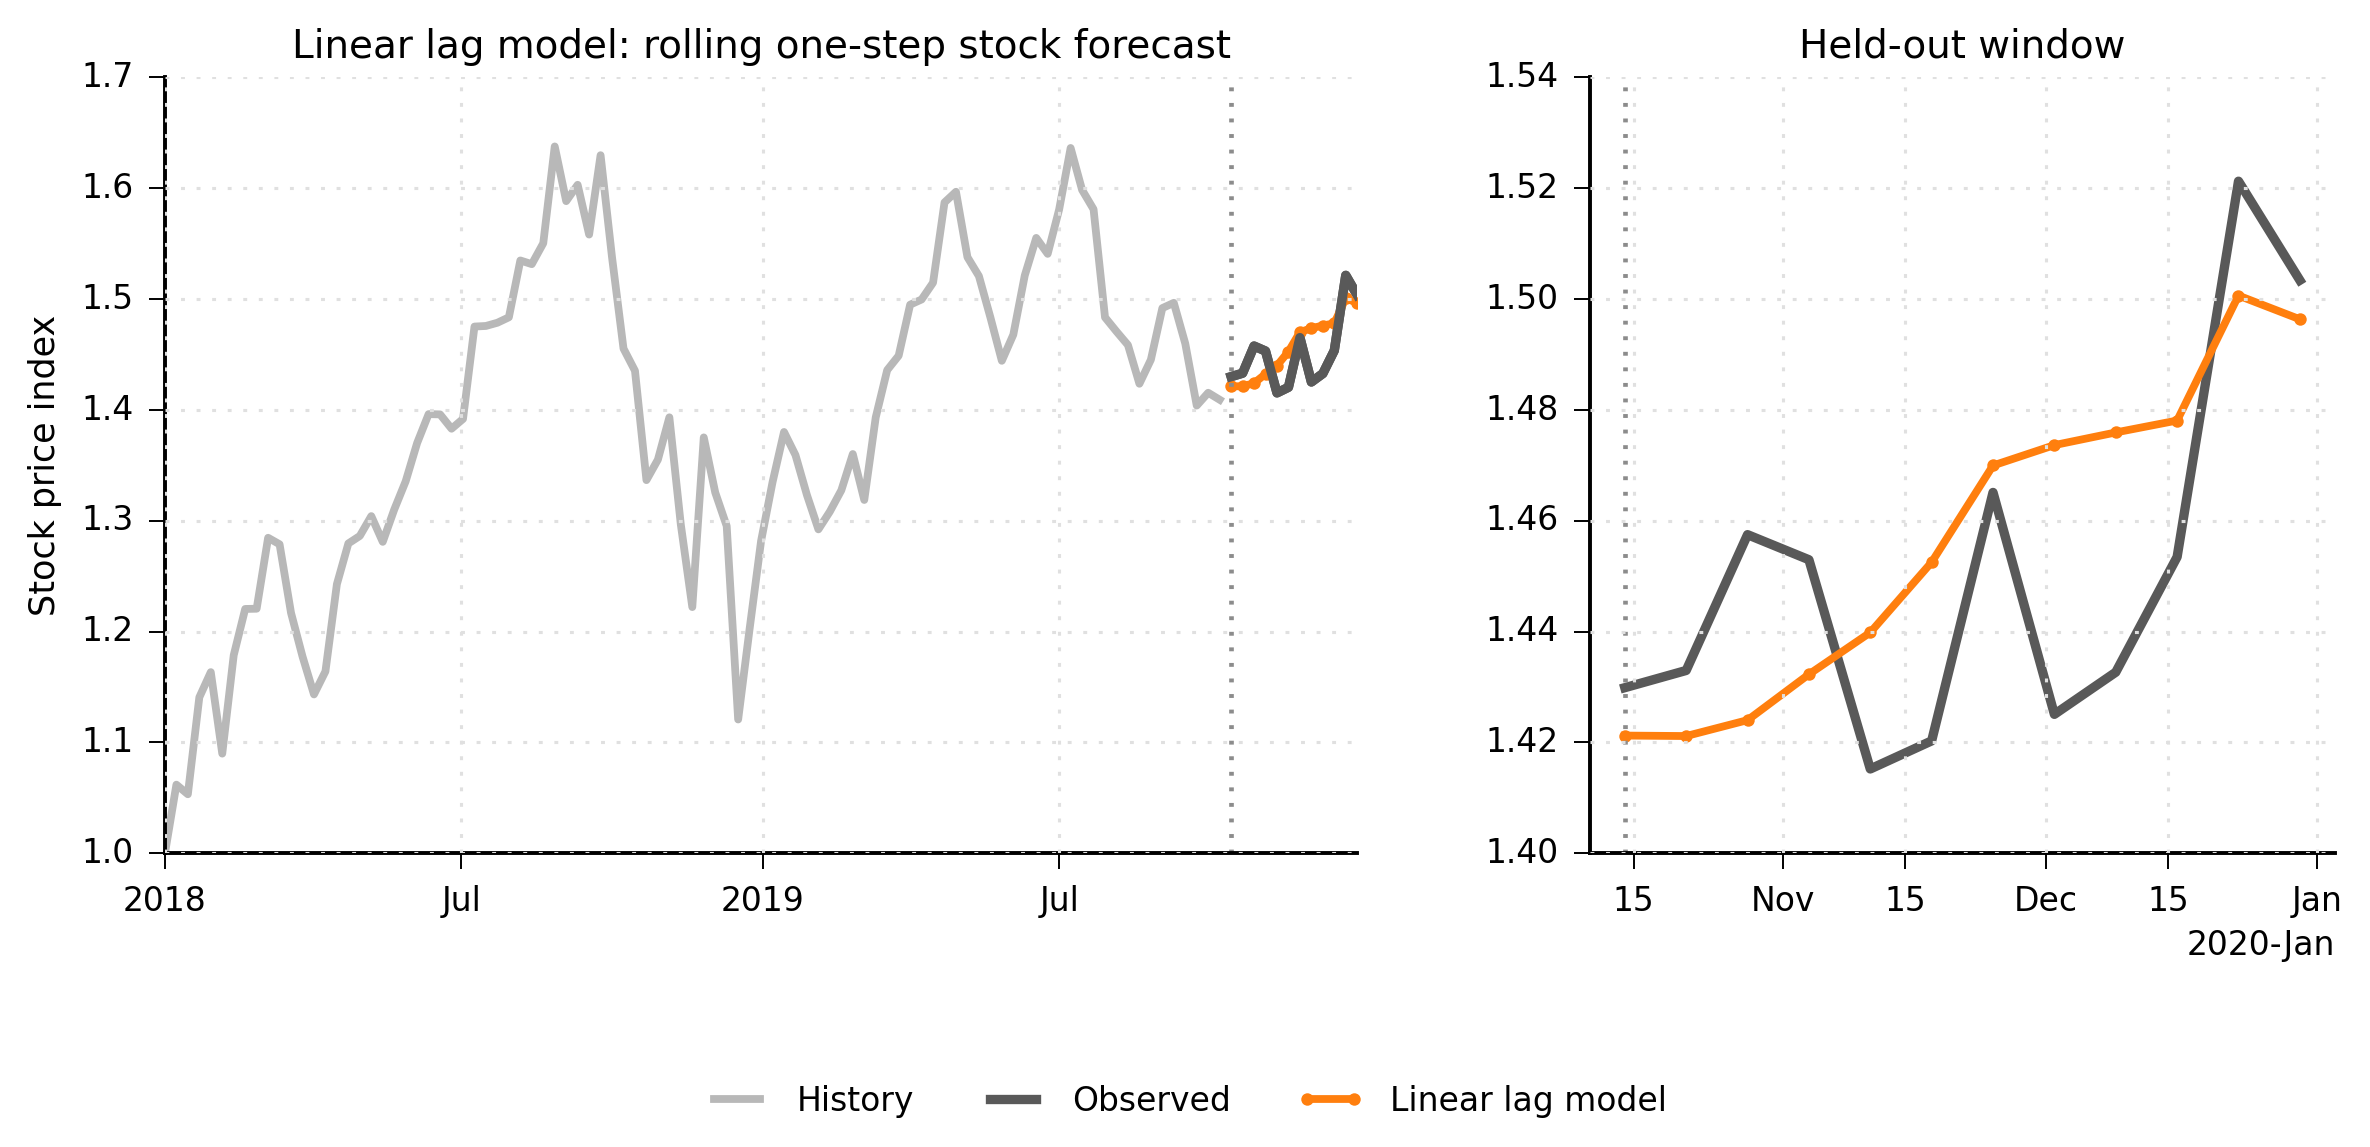

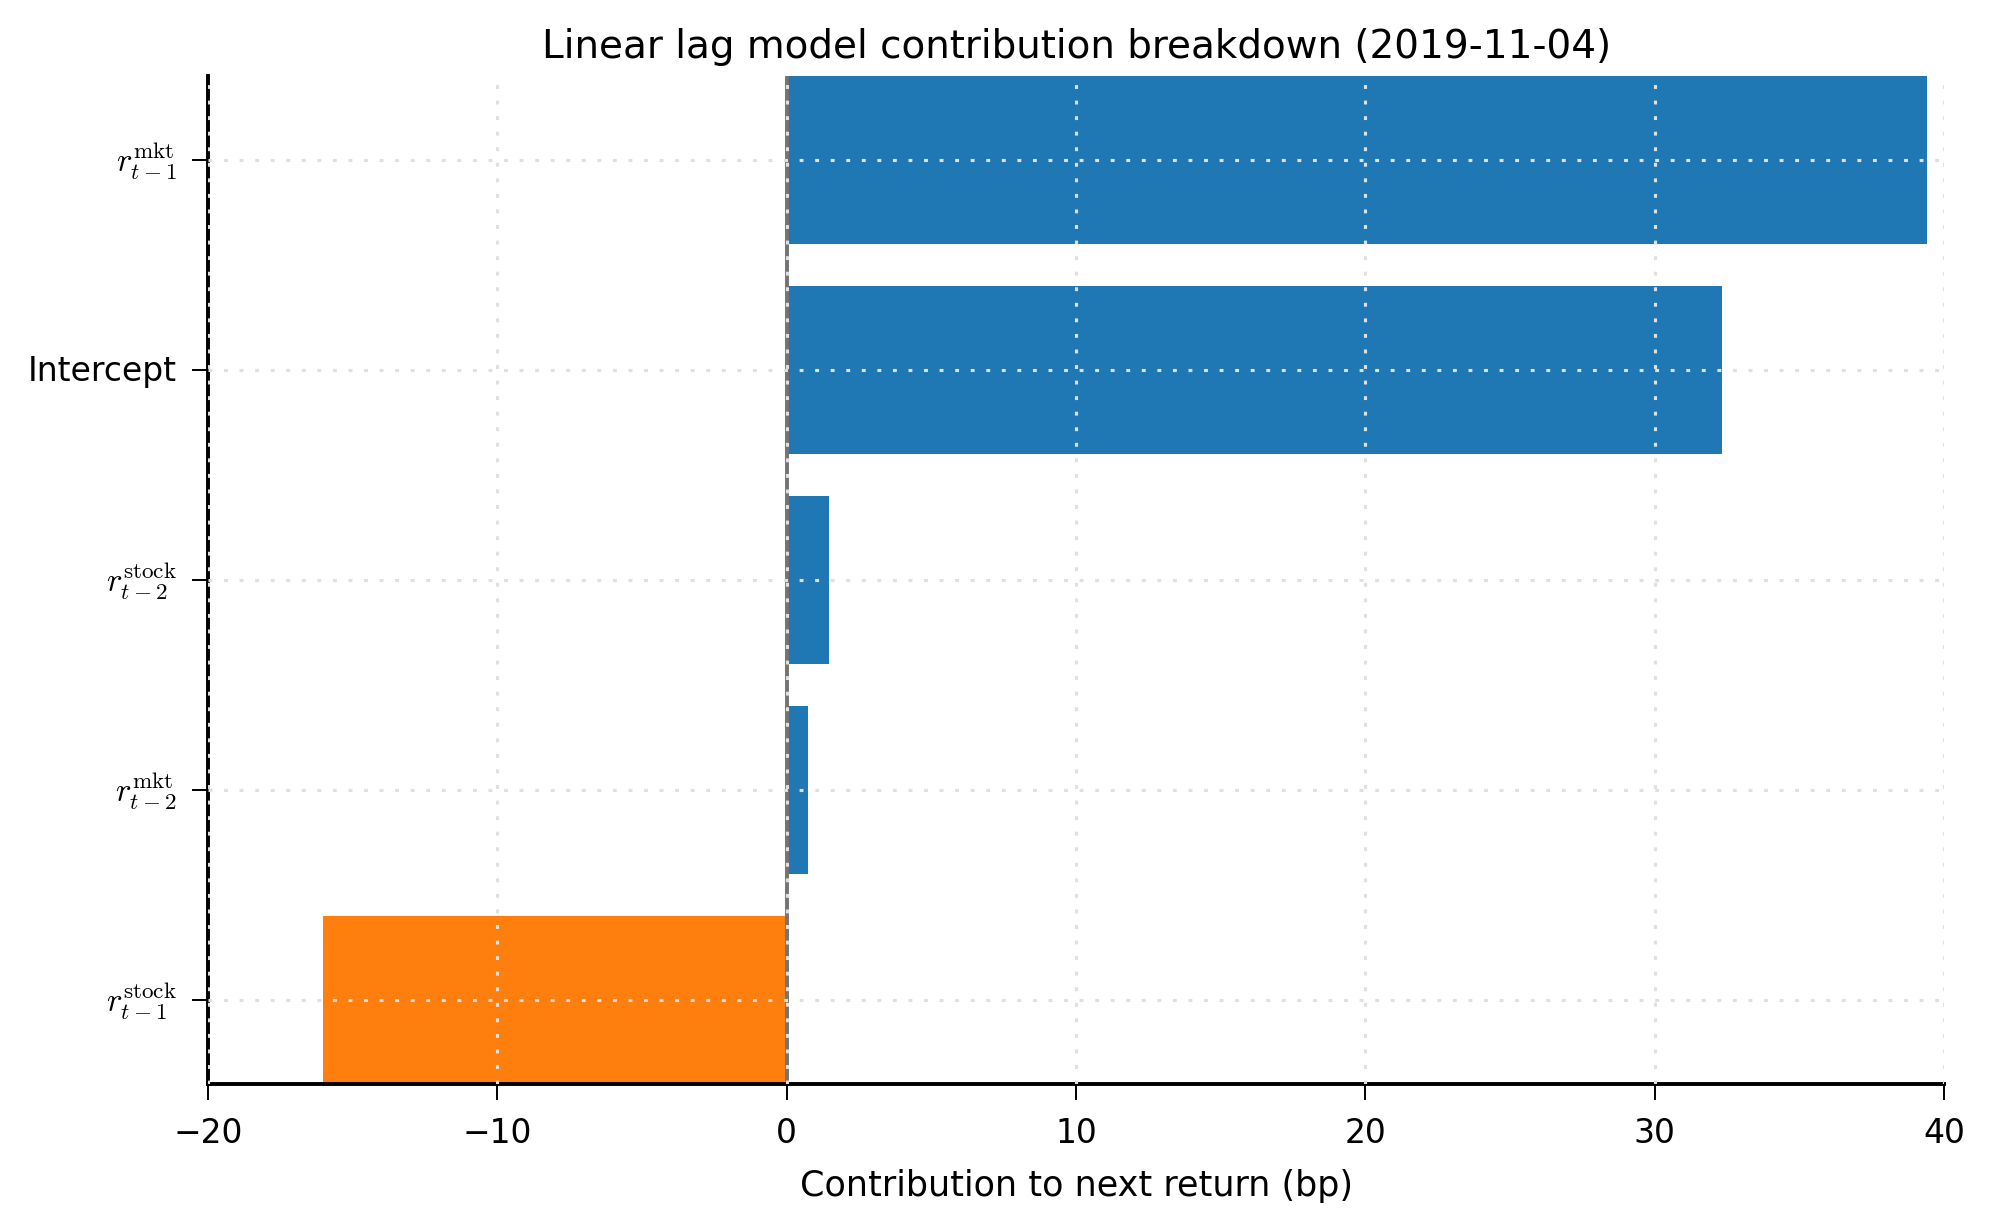

In [6]:
def fit_ridge_model(
    feature_frame: pd.DataFrame,
    target: pd.Series,
    lambda_: float,
    feature_labels: tuple[str, ...] | None = None,
) -> dict:
    x = torch.as_tensor(feature_frame.to_numpy(), dtype=torch.float64, device=DEVICE)
    y = torch.as_tensor(target.to_numpy(), dtype=torch.float64, device=DEVICE)
    mean = x.mean(dim=0)
    scale = x.std(dim=0)
    scale = torch.where(scale < 1e-12, torch.ones_like(scale), scale)
    x_design = add_intercept_column((x - mean) / scale)
    penalty = torch.eye(x_design.shape[1], dtype=torch.float64, device=DEVICE)
    penalty[0, 0] = 0.0
    coef = torch.linalg.solve(x_design.T @ x_design + lambda_ * penalty, x_design.T @ y)
    if feature_labels is None:
        feature_labels = tuple(feature_frame.columns)
    return {"coef": coef, "mean": mean, "scale": scale, "feature_labels": feature_labels}


def predict_ridge_model(model: dict, feature_frame: pd.DataFrame) -> torch.Tensor:
    x = torch.as_tensor(feature_frame.to_numpy(), dtype=torch.float64, device=DEVICE)
    x_design = add_intercept_column((x - model["mean"]) / model["scale"])
    return x_design @ model["coef"]


def ridge_contributions(model: dict, row: pd.Series) -> pd.Series:
    x = torch.as_tensor(row.to_numpy(), dtype=torch.float64, device=DEVICE)
    x_std = (x - model["mean"]) / model["scale"]
    values = {"Intercept": float(model["coef"][0])}
    for idx, label in enumerate(model["feature_labels"]):
        values[label] = float(model["coef"][idx + 1] * x_std[idx])
    series = pd.Series(values, name="contribution")
    series["Prediction"] = float(series.sum())
    return series


linear_model = fit_ridge_model(train_features, train_target, lambda_=LAMBDA, feature_labels=FEATURE_LABELS)
linear_pred_returns = predict_ridge_model(linear_model, test_features)
linear_pred_prices = to_named_series(
    returns_to_price_path(history_prices.iloc[-1], linear_pred_returns),
    test_features.index,
    "Linear lag model",
)
linear_contrib = ridge_contributions(linear_model, test_features.loc[example_date])

linear_metrics = {
    "model": "Linear lag model",
    "price_MAPE_pct": mape_percent(actual_prices, linear_pred_prices),
    "return_RMSE_bp": rmse_basis_points(
        torch.as_tensor(test_target.to_numpy(), dtype=torch.float64, device=DEVICE),
        linear_pred_returns,
    ),
}
display(pd.Series(linear_metrics).to_frame("value"))

plot_forecast(
    history_prices,
    actual_prices,
    {"Linear lag model": linear_pred_prices},
    "Linear lag model: rolling one-step stock forecast",
    "02_linear_lag_forecast",
)
plot_contributions(
    linear_contrib,
    f"Linear lag model contribution breakdown ({example_date:%Y-%m-%d})",
    "03_linear_lag_contributions",
)
plt.show()

## GAM

,value
model,GAM
price_MAPE_pct,1.424993
return_RMSE_bp,174.545888


saved: out/finance_lag_model_graphics/04_gam_effect_curves.pdf
saved: out/finance_lag_model_graphics/04_gam_effect_curves.png
saved: out/finance_lag_model_graphics/05_gam_forecast_comparison.pdf
saved: out/finance_lag_model_graphics/05_gam_forecast_comparison.png


saved: out/finance_lag_model_graphics/06_gam_contributions.pdf
saved: out/finance_lag_model_graphics/06_gam_contributions.png


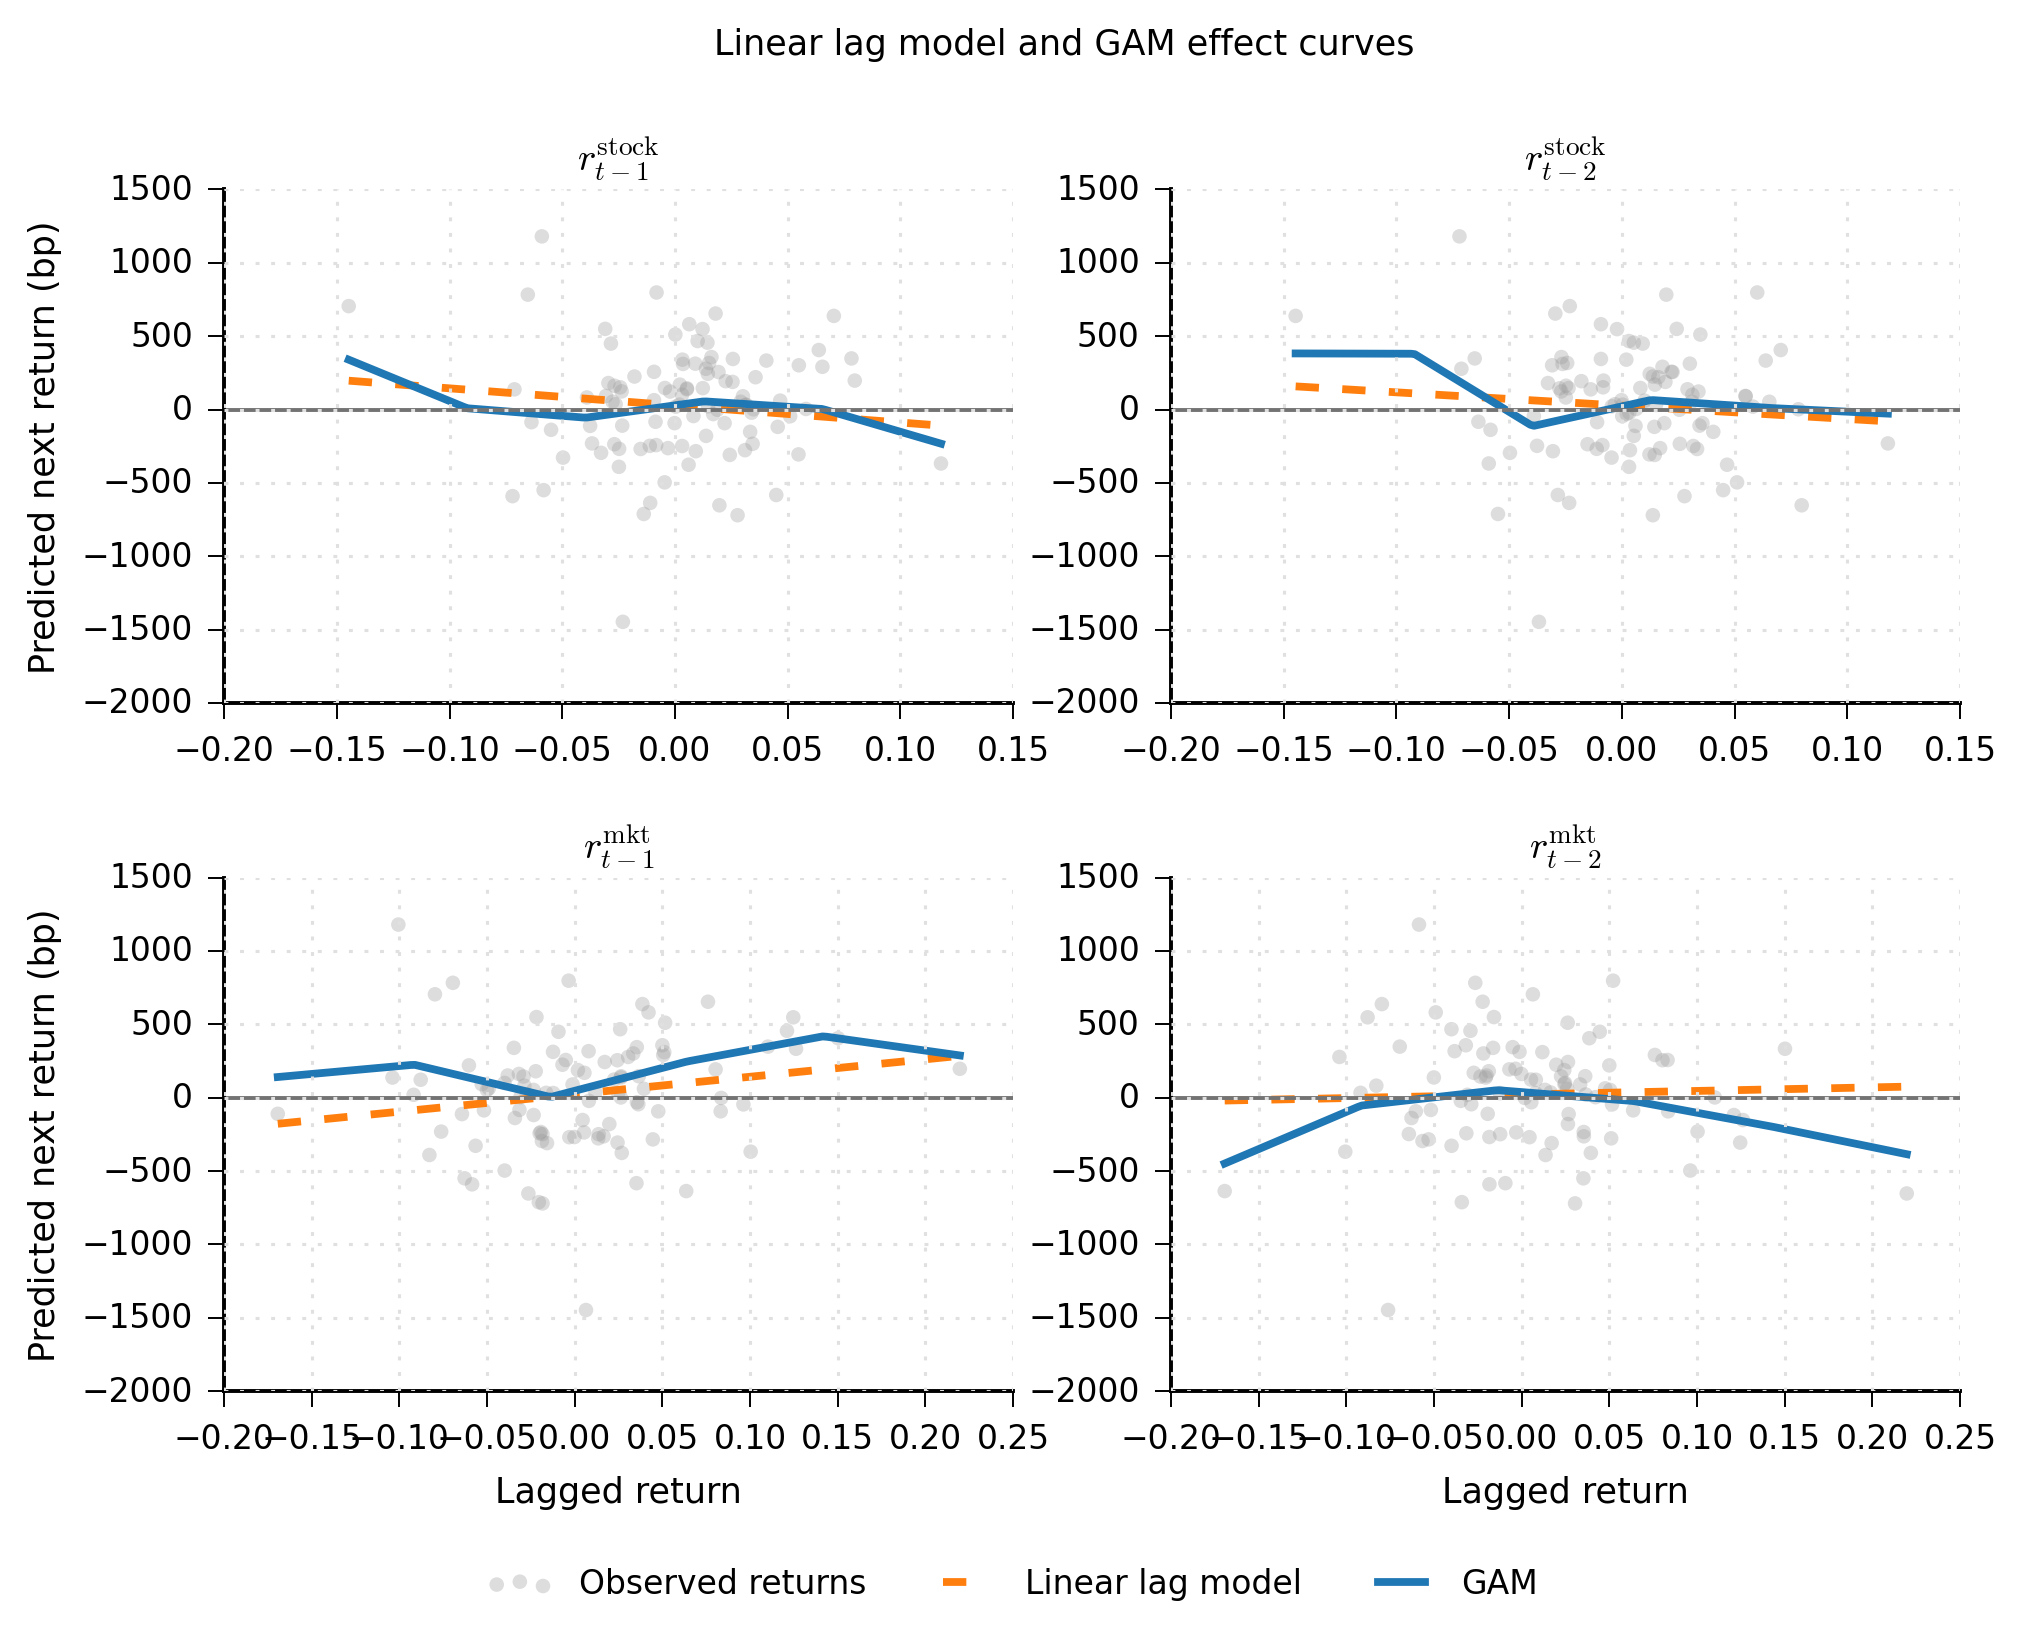

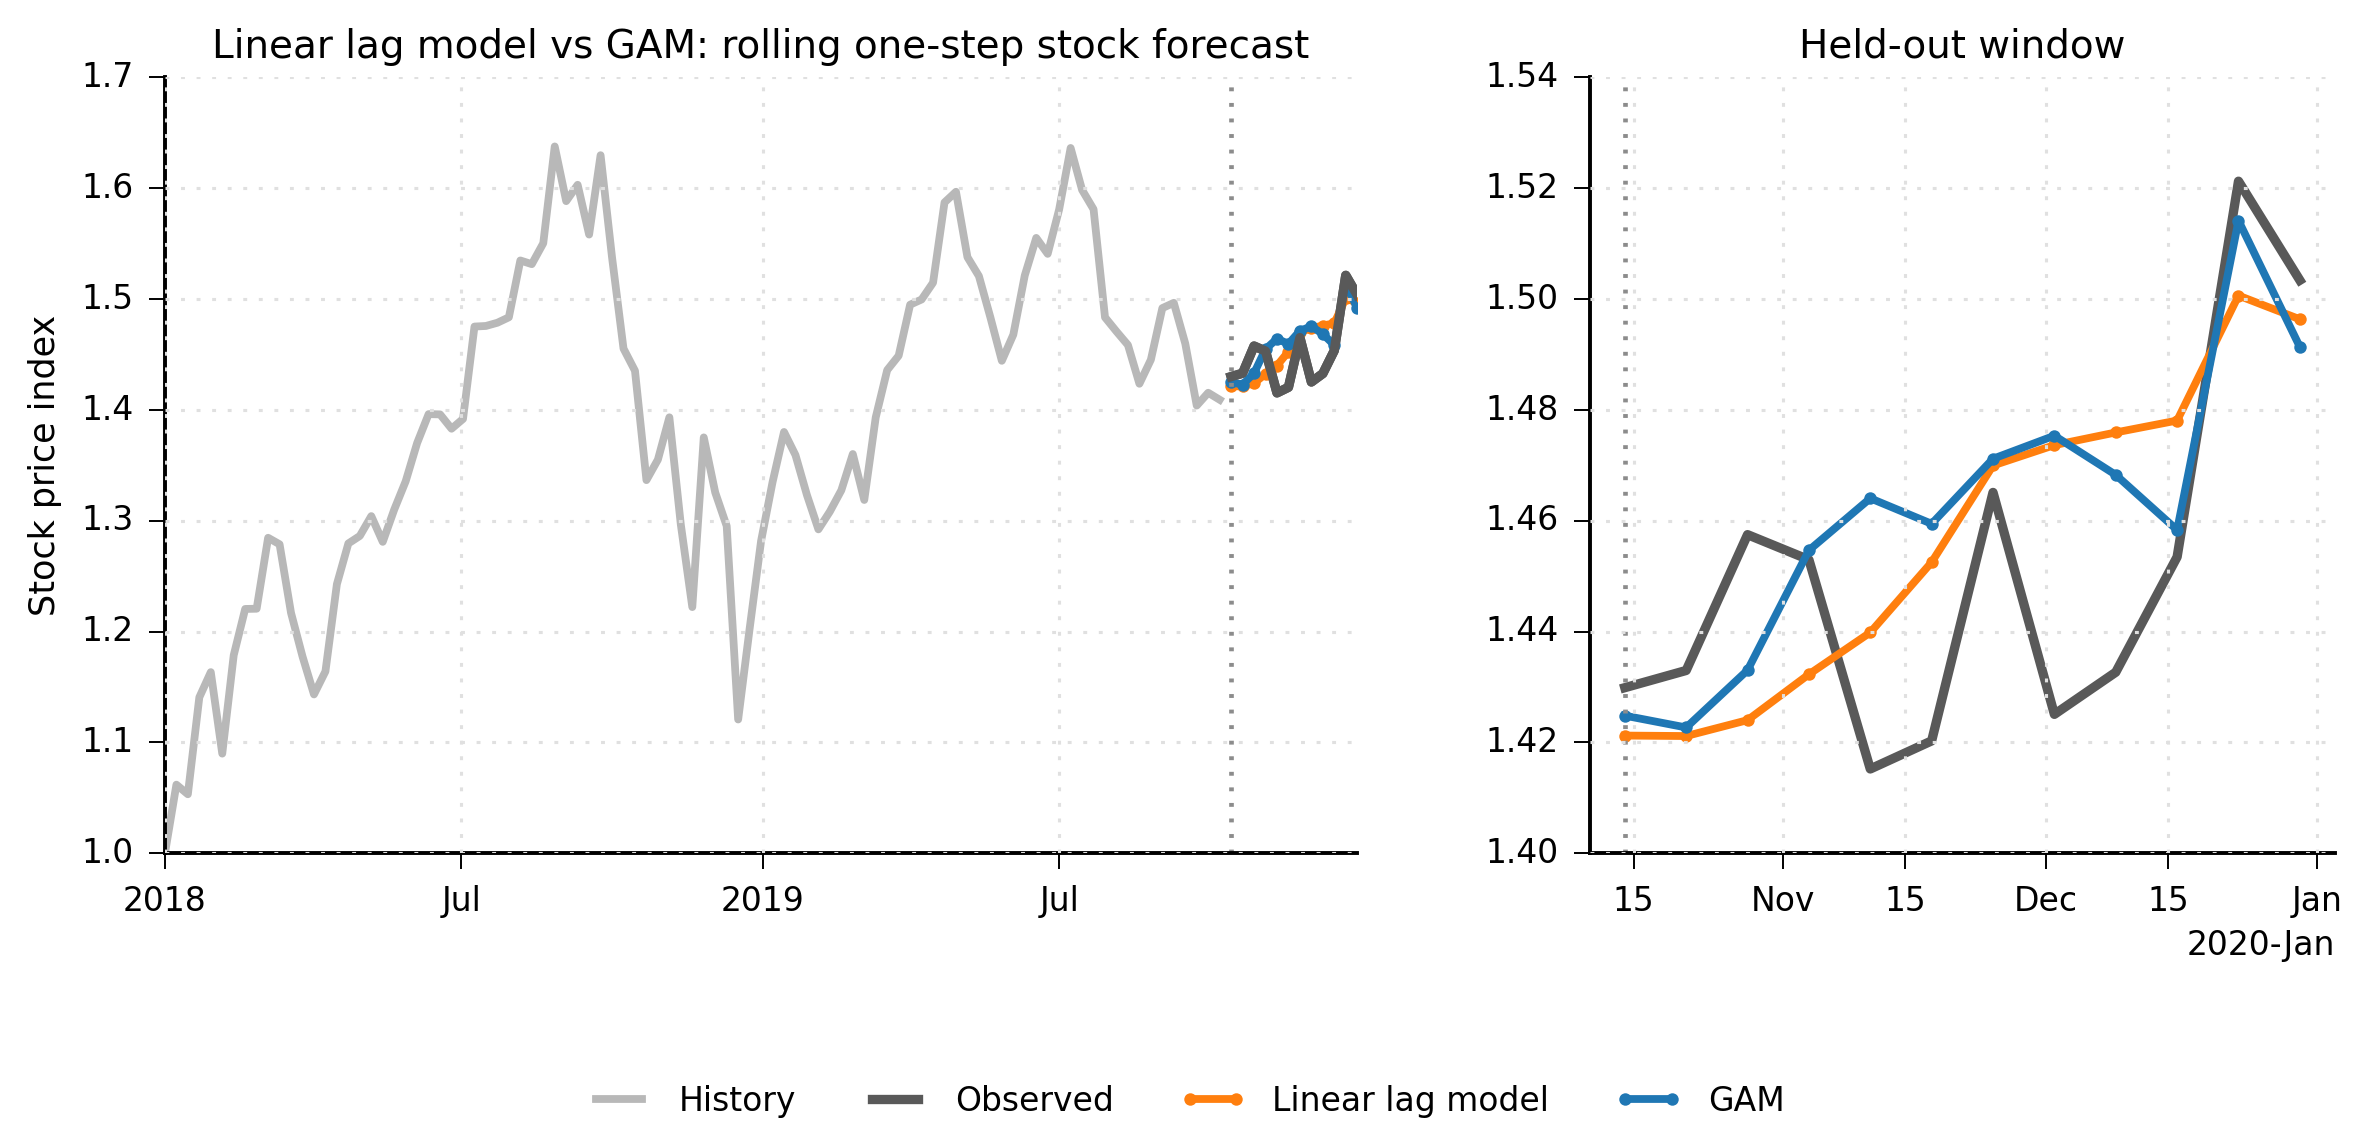

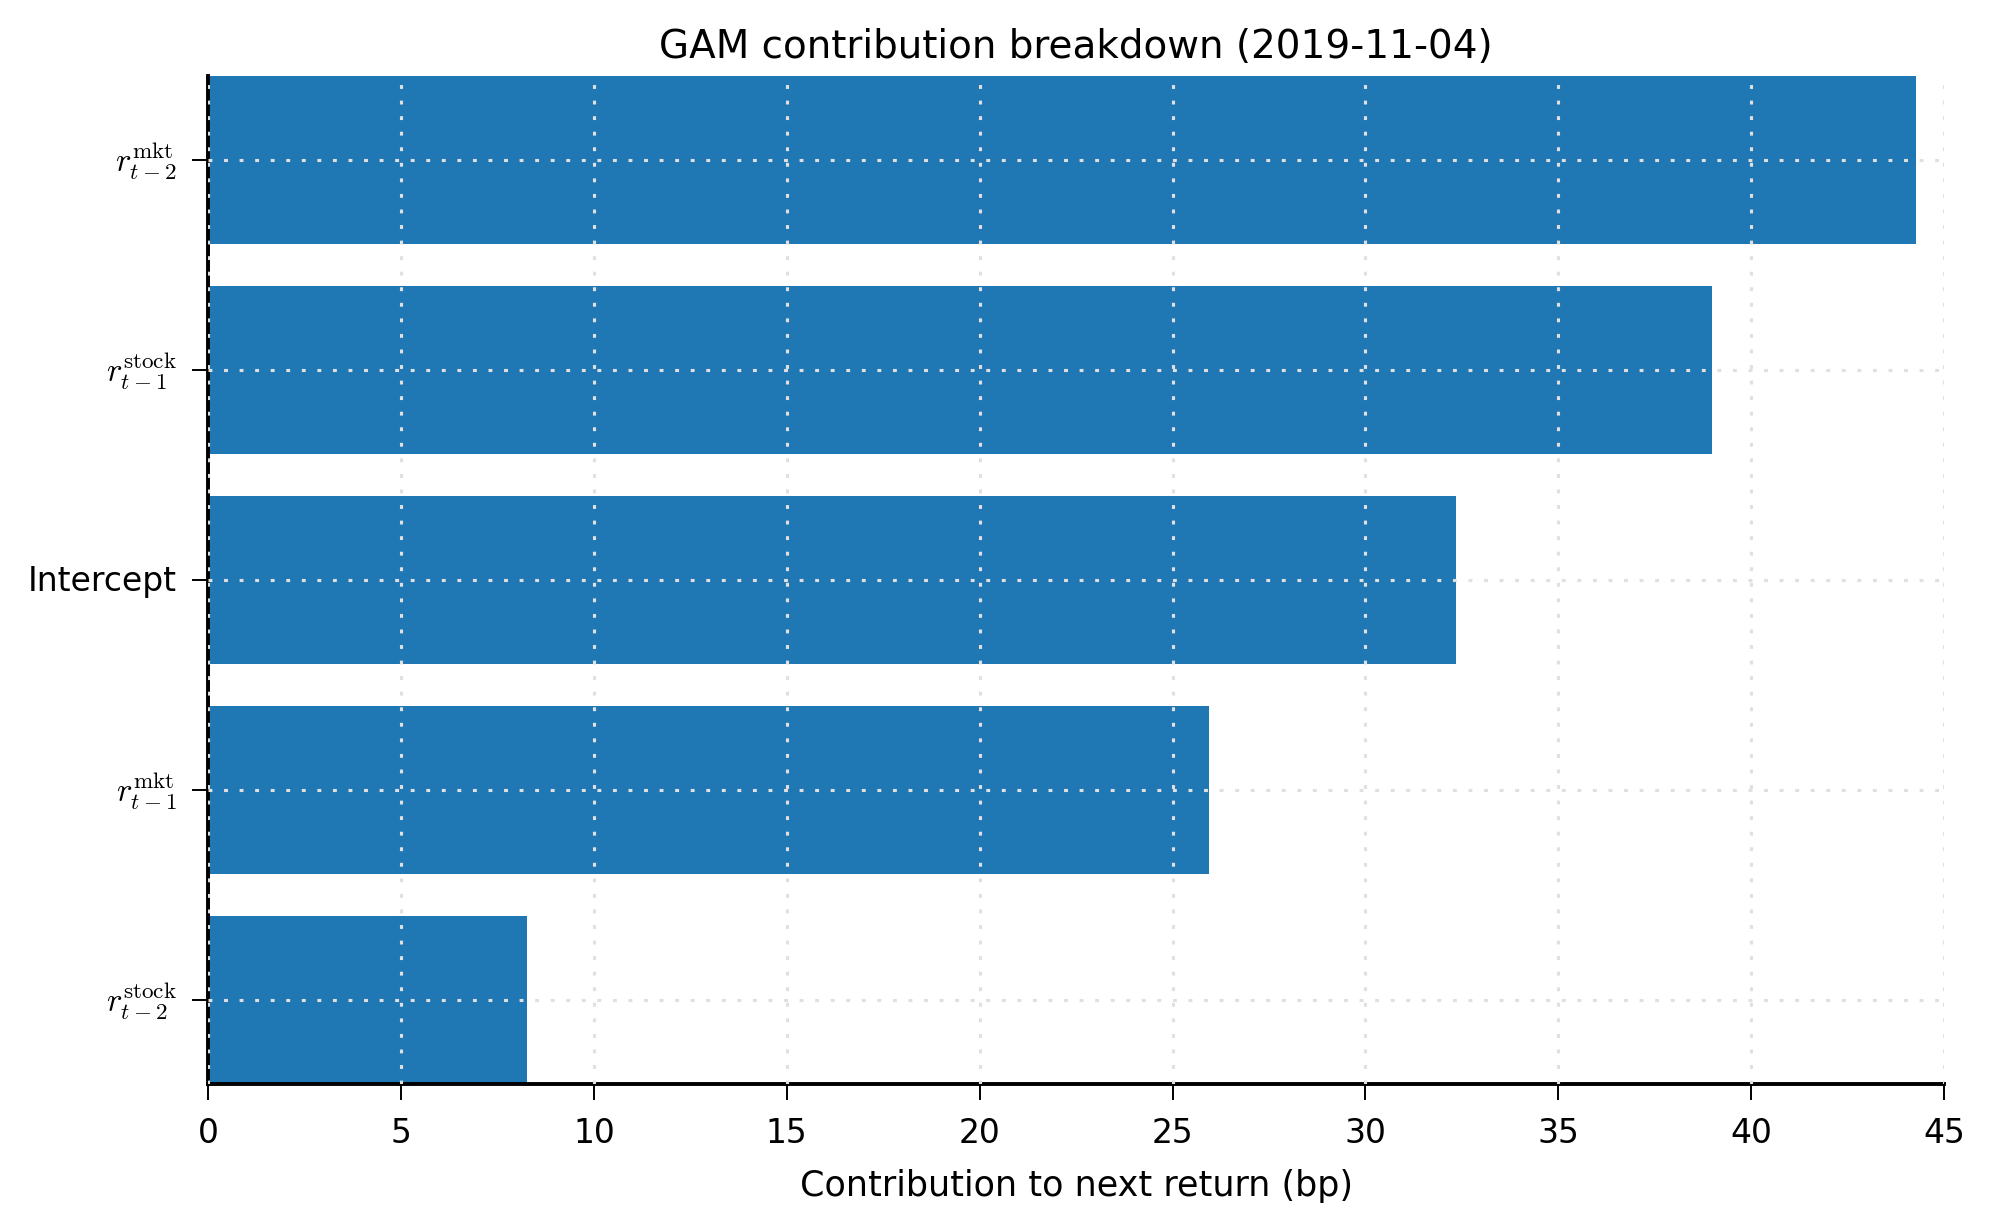

In [7]:
def make_triangular_knots(feature_frame: pd.DataFrame, n_splines: int) -> list[torch.Tensor]:
    x = torch.as_tensor(feature_frame.to_numpy(), dtype=torch.float64, device=DEVICE)
    return [torch.linspace(x[:, j].min(), x[:, j].max(), n_splines, device=DEVICE) for j in range(x.shape[1])]


def triangular_basis(column: torch.Tensor, knots: torch.Tensor) -> torch.Tensor:
    if len(knots) <= 1 or torch.isclose(knots[-1], knots[0]):
        width = torch.tensor(1.0, dtype=torch.float64, device=DEVICE)
    else:
        width = (knots[-1] - knots[0]) / (len(knots) - 1)
    return torch.clamp(1.0 - torch.abs((column[:, None] - knots[None, :]) / width), min=0.0)


def gam_basis_parts(feature_frame: pd.DataFrame, knots: list[torch.Tensor]) -> list[torch.Tensor]:
    x = torch.as_tensor(feature_frame.to_numpy(), dtype=torch.float64, device=DEVICE)
    return [triangular_basis(x[:, j], knot) for j, knot in enumerate(knots)]


def fit_gam_model(feature_frame: pd.DataFrame, target: pd.Series, n_splines: int, lambda_: float) -> dict:
    knots = make_triangular_knots(feature_frame, n_splines)
    parts = gam_basis_parts(feature_frame, knots)
    centers = [part.mean(dim=0, keepdim=True) for part in parts]
    design = torch.cat([part - center for part, center in zip(parts, centers)], dim=1)
    y = torch.as_tensor(target.to_numpy(), dtype=torch.float64, device=DEVICE)
    design_with_intercept = add_intercept_column(design)
    penalty = torch.eye(design_with_intercept.shape[1], dtype=torch.float64, device=DEVICE)
    penalty[0, 0] = 0.0
    coef = torch.linalg.solve(
        design_with_intercept.T @ design_with_intercept + lambda_ * penalty,
        design_with_intercept.T @ y,
    )
    return {
        "coef": coef,
        "knots": knots,
        "centers": centers,
        "n_splines": n_splines,
        "feature_labels": FEATURE_LABELS,
    }


def gam_design(model: dict, feature_frame: pd.DataFrame) -> torch.Tensor:
    parts = gam_basis_parts(feature_frame, model["knots"])
    centered = [part - center for part, center in zip(parts, model["centers"])]
    return torch.cat(centered, dim=1)


def predict_gam_model(model: dict, feature_frame: pd.DataFrame) -> torch.Tensor:
    return add_intercept_column(gam_design(model, feature_frame)) @ model["coef"]


def gam_contributions(model: dict, row: pd.Series) -> pd.Series:
    one_row = row.to_frame().T
    parts = gam_basis_parts(one_row, model["knots"])
    values = {"Intercept": float(model["coef"][0])}
    offset = 1
    for idx, label in enumerate(model["feature_labels"]):
        centered = parts[idx] - model["centers"][idx]
        width = model["n_splines"]
        values[label] = float(centered @ model["coef"][offset : offset + width])
        offset += width
    series = pd.Series(values, name="contribution")
    series["Prediction"] = float(series.sum())
    return series


def effect_curve_frame(model: dict, feature_frame: pd.DataFrame, model_name: str) -> pd.DataFrame:
    anchor = feature_frame.median().to_frame().T
    rows = []
    for feature_index, feature_name in enumerate(feature_frame.columns):
        grid = torch.linspace(
            float(feature_frame[feature_name].min()),
            float(feature_frame[feature_name].max()),
            160,
            device=DEVICE,
        ).detach().cpu().numpy()
        grid_frame = pd.concat([anchor] * len(grid), ignore_index=True)
        grid_frame[feature_name] = grid
        if model_name == "GAM":
            prediction = predict_gam_model(model, grid_frame)
        else:
            prediction = predict_ridge_model(model, grid_frame)
        rows.append(
            pd.DataFrame(
                {
                    "model": model_name,
                    "feature": feature_name,
                    "feature_label": FEATURE_LABELS[feature_index],
                    "feature_value": grid,
                    "prediction": prediction.detach().cpu().numpy(),
                }
            )
        )
    return pd.concat(rows, ignore_index=True)


gam_model = fit_gam_model(train_features, train_target, n_splines=GAM_N_SPLINES, lambda_=LAMBDA)
gam_pred_returns = predict_gam_model(gam_model, test_features)
gam_pred_prices = to_named_series(
    returns_to_price_path(history_prices.iloc[-1], gam_pred_returns),
    test_features.index,
    "GAM",
)
gam_contrib = gam_contributions(gam_model, test_features.loc[example_date])
gam_metrics = {
    "model": "GAM",
    "price_MAPE_pct": mape_percent(actual_prices, gam_pred_prices),
    "return_RMSE_bp": rmse_basis_points(
        torch.as_tensor(test_target.to_numpy(), dtype=torch.float64, device=DEVICE),
        gam_pred_returns,
    ),
}
display(pd.Series(gam_metrics).to_frame("value"))

effect_curves = pd.concat(
    [effect_curve_frame(linear_model, train_features, "Linear lag model"), effect_curve_frame(gam_model, train_features, "GAM")],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 2, figsize=(8.0, 5.8))
axes = axes.ravel()
feature_names = list(train_features.columns)
for ax, feature_name, feature_label in zip(axes, feature_names, FEATURE_LABELS):
    ax.scatter(
        features[feature_name],
        target_returns.loc[features.index] * 1e4,
        color="0.62",
        alpha=0.35,
        s=14,
        edgecolors="none",
        linewidths=0,
        label="Observed returns",
    )
    for model_name in ("Linear lag model", "GAM"):
        curve = effect_curves[(effect_curves["feature"] == feature_name) & (effect_curves["model"] == model_name)]
        linestyle = "--" if model_name == "Linear lag model" else "-"
        ax.plot(
            curve["feature_value"],
            curve["prediction"] * 1e4,
            color=MODEL_COLORS[model_name],
            linestyle=linestyle,
            label=model_name,
        )
    ax.axhline(0.0, color="0.45", linewidth=1)
    ax.set_title(feature_label)
for idx, ax in enumerate(axes):
    ax.set_xlabel("Lagged return" if idx >= 2 else "")
    ax.set_ylabel("Predicted next return (bp)" if idx % 2 == 0 else "")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Linear lag model and GAM effect curves")
fig.subplots_adjust(bottom=0.14, top=0.88, hspace=0.34, wspace=0.20)
save_plot(fig, "04_gam_effect_curves")

plot_forecast(
    history_prices,
    actual_prices,
    {"Linear lag model": linear_pred_prices, "GAM": gam_pred_prices},
    "Linear lag model vs GAM: rolling one-step stock forecast",
    "05_gam_forecast_comparison",
)
plot_contributions(
    gam_contrib,
    f"GAM contribution breakdown ({example_date:%Y-%m-%d})",
    "06_gam_contributions",
)
plt.show()

## VAR

This regenerates the slide 52 idea with the official exercise data: a rolling one-step forecast for both the stock and market proxy.

,value
model,VAR
price_MAPE_pct,1.6393
return_RMSE_bp,178.407966


saved: out/finance_lag_model_graphics/07_var_rolling_forecast_summary.pdf
saved: out/finance_lag_model_graphics/07_var_rolling_forecast_summary.png
saved: out/finance_lag_model_graphics/08_var_stock_contributions.pdf
saved: out/finance_lag_model_graphics/08_var_stock_contributions.png


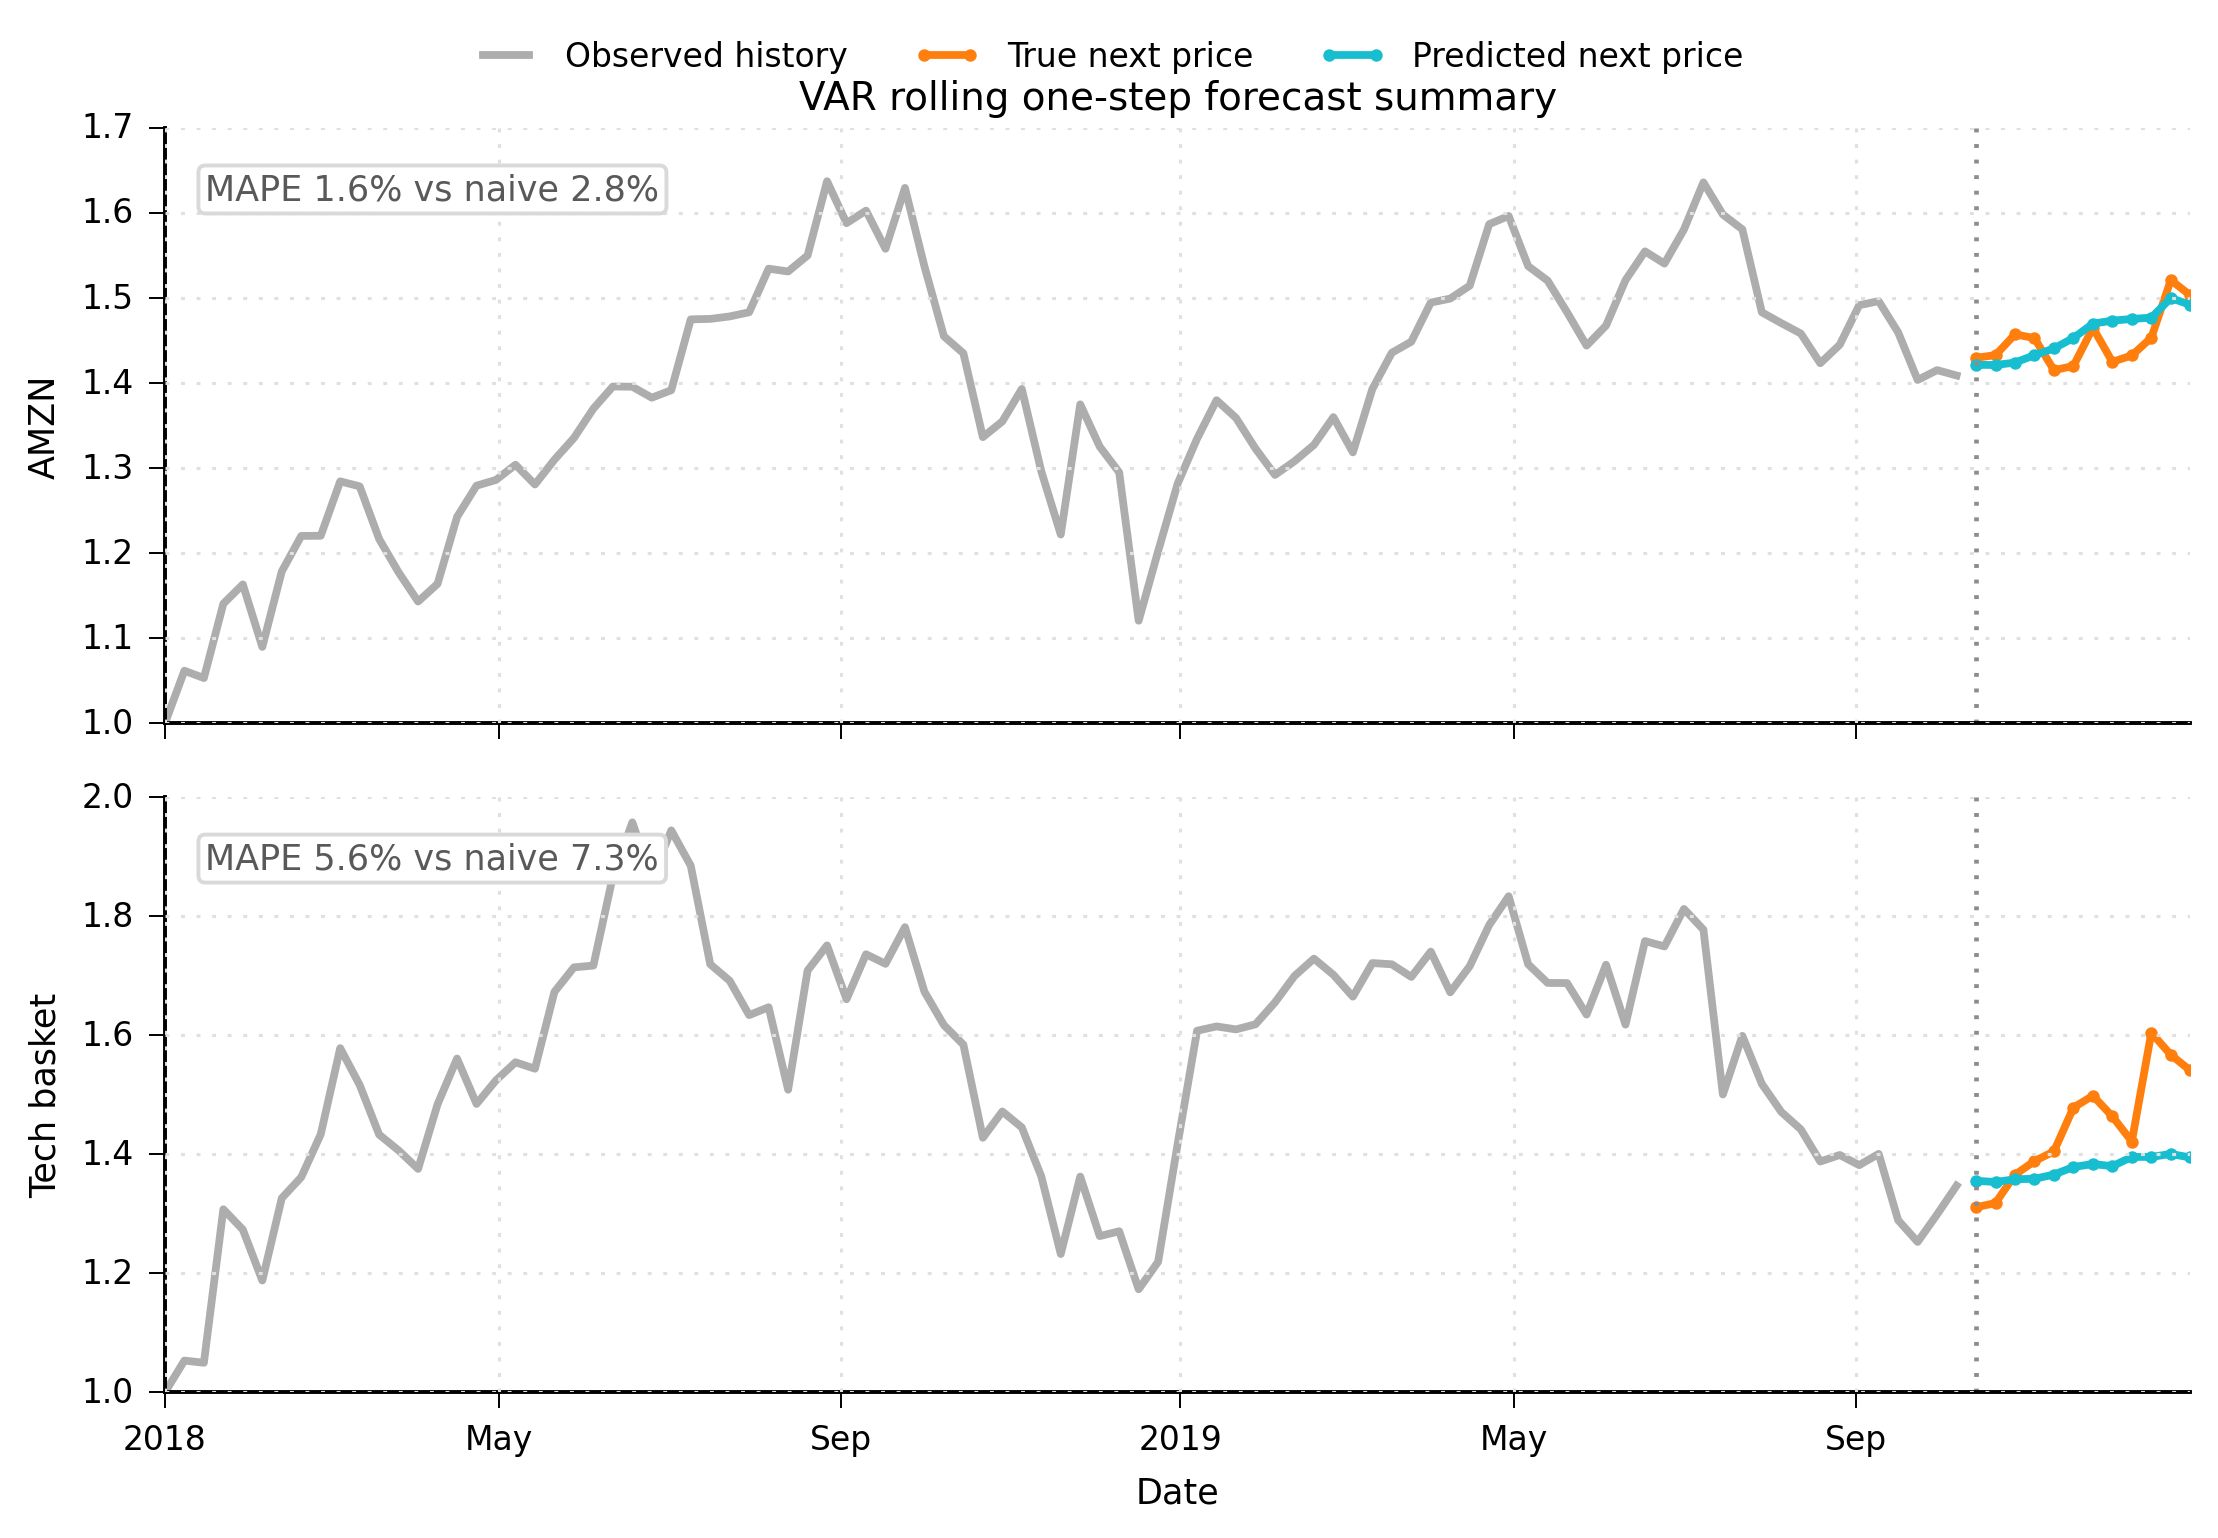

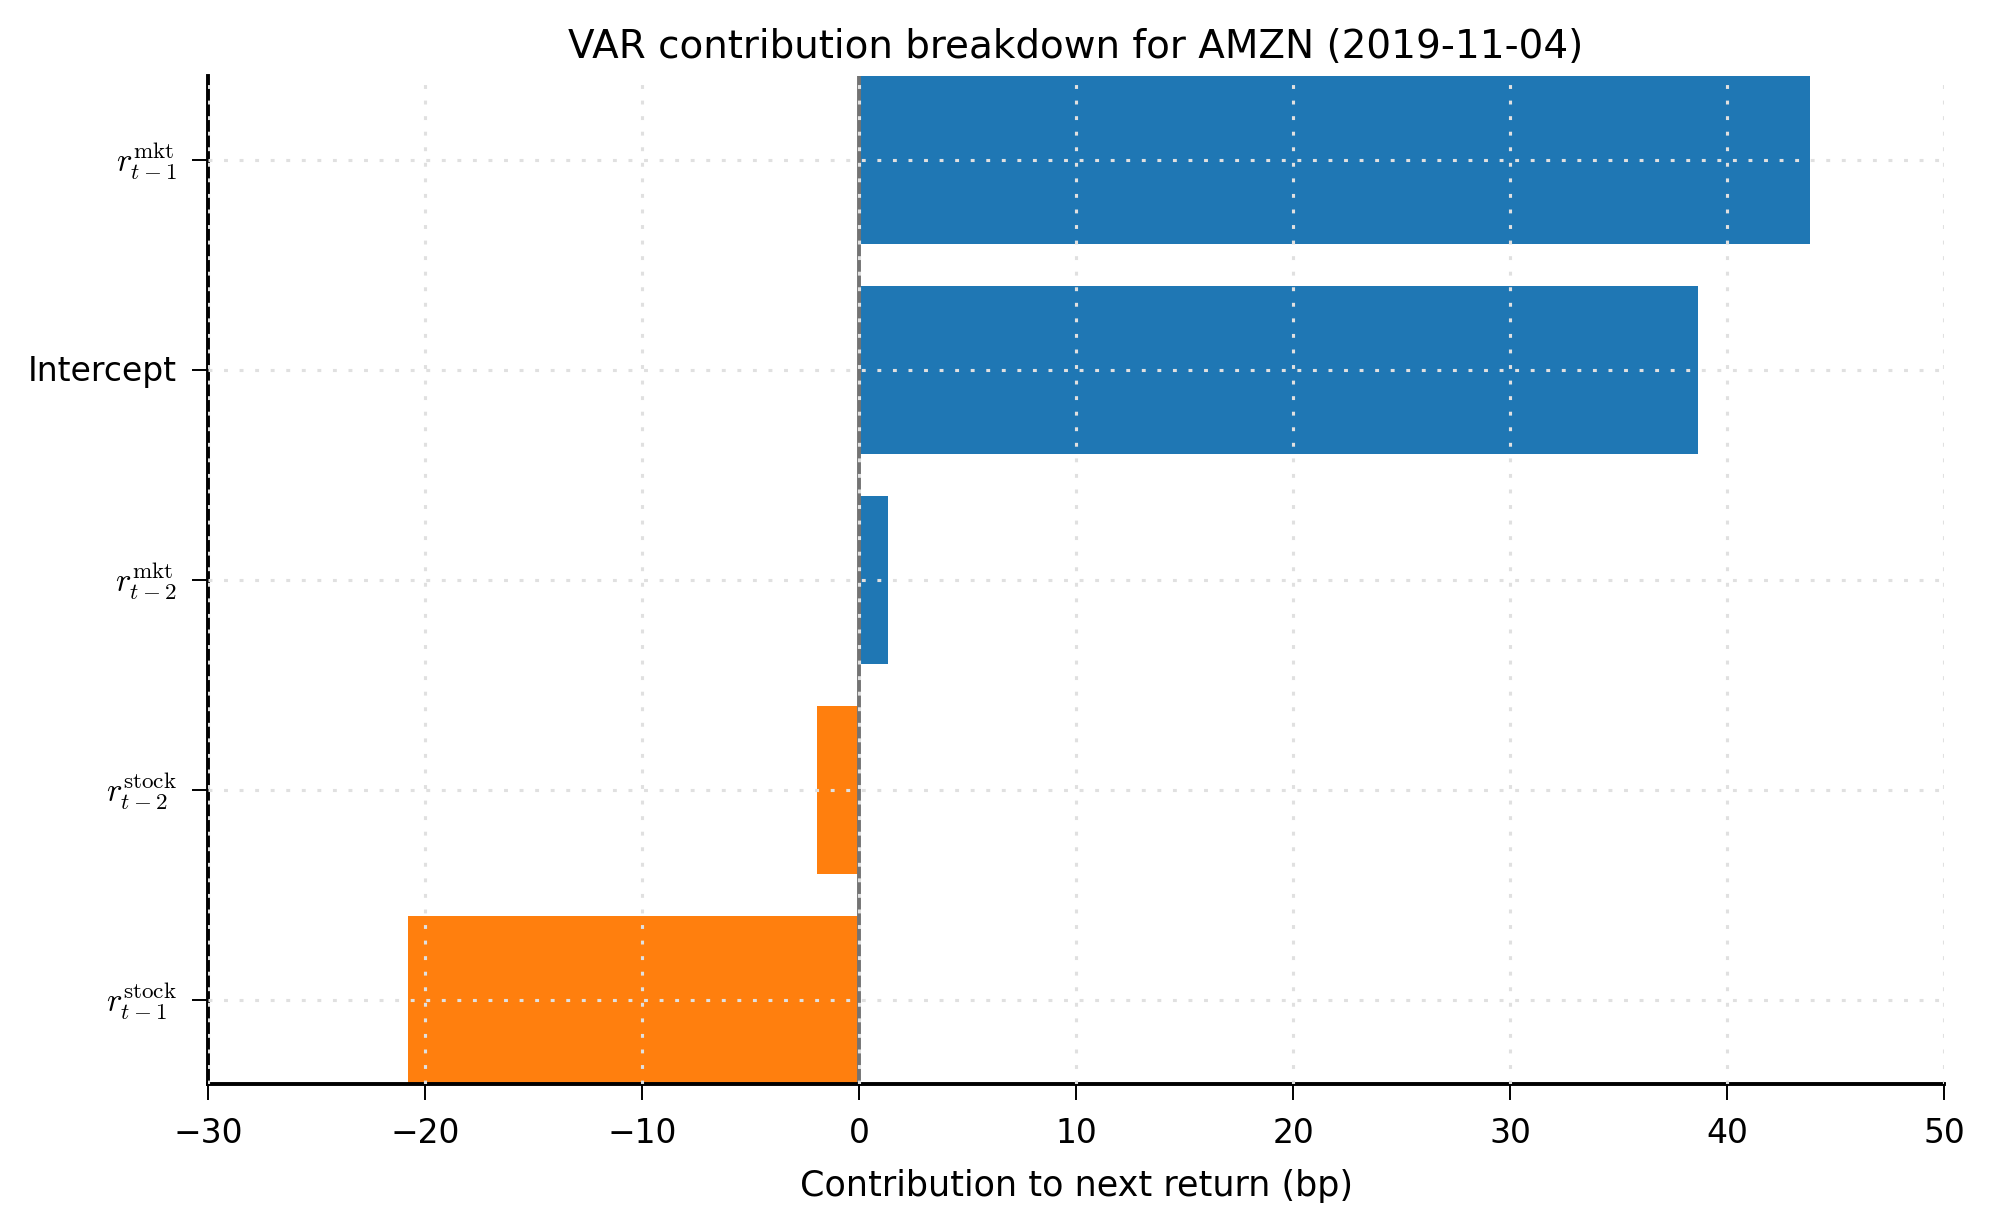

In [8]:
def make_var_xy(return_frame: pd.DataFrame, lag: int) -> tuple[torch.Tensor, torch.Tensor]:
    values = torch.as_tensor(return_frame.to_numpy(), dtype=torch.float64, device=DEVICE)
    rows = []
    targets = []
    for t in range(lag, len(values)):
        row_parts = [values[t - lag_number] for lag_number in range(1, lag + 1)]
        rows.append(torch.cat(row_parts))
        targets.append(values[t])
    x = torch.stack(rows)
    y = torch.stack(targets)
    return x, y


def fit_var_model(return_frame: pd.DataFrame, lag: int, lambda_: float = 1e-6) -> dict:
    x, y = make_var_xy(return_frame, lag)
    x_design = add_intercept_column(x)
    penalty = torch.eye(x_design.shape[1], dtype=torch.float64, device=DEVICE)
    penalty[0, 0] = 0.0
    coef = torch.linalg.solve(x_design.T @ x_design + lambda_ * penalty, x_design.T @ y)
    return {"coef": coef, "lag": lag, "columns": tuple(return_frame.columns)}


def forecast_var_model(model: dict, history: pd.DataFrame) -> torch.Tensor:
    values = torch.as_tensor(history.to_numpy(), dtype=torch.float64, device=DEVICE)
    row = torch.cat([values[-lag_number] for lag_number in range(1, model["lag"] + 1)])
    return add_intercept_column(row[None, :]) @ model["coef"]


def rolling_var_forecast(train_returns: pd.DataFrame, future_returns: pd.DataFrame, lag: int) -> tuple[pd.DataFrame, dict]:
    history = train_returns.copy()
    predictions = []
    snapshots = {}
    for timestamp in future_returns.index:
        model = fit_var_model(history, lag=lag)
        prediction = forecast_var_model(model, history)
        predictions.append(prediction.detach().cpu().numpy().ravel())
        snapshots[timestamp] = {"model": model, "history": history.copy()}
        history.loc[timestamp] = future_returns.loc[timestamp]
    prediction_frame = pd.DataFrame(predictions, index=future_returns.index, columns=train_returns.columns)
    return prediction_frame, snapshots


def var_contributions(snapshot: dict, target: str) -> pd.Series:
    model = snapshot["model"]
    history = snapshot["history"]
    columns = list(model["columns"])
    target_index = columns.index(target)
    values = {"Intercept": float(model["coef"][0, target_index])}
    offset = 1
    for lag_number in range(1, model["lag"] + 1):
        observation = history.iloc[-lag_number]
        for source in columns:
            source_index = columns.index(source)
            coef_value = model["coef"][offset + source_index, target_index]
            label = rf"$r_{{t-{lag_number}}}^{{\mathrm{{{source}}}}}$"
            values[label] = float(coef_value * observation[source])
        offset += len(columns)
    series = pd.Series(values, name="contribution")
    series["Prediction"] = float(series.sum())
    return series


def plot_var_forecast_summary(
    train_price_frame: pd.DataFrame,
    actual_price_frame: pd.DataFrame,
    predicted_price_frame: pd.DataFrame,
    baseline_price_frame: pd.DataFrame,
    name: str,
):
    fig, axes = plt.subplots(2, 1, figsize=PANEL_FIGSIZE, sharex=True)
    for ax, column in zip(axes, (STOCK, MKT)):
        ax.plot(train_price_frame.index, train_price_frame[column], color="0.68", linewidth=2.0, label="Observed history")
        ax.plot(
            actual_price_frame.index,
            actual_price_frame[column],
            color=MODEL_COLORS["Observed"],
            marker="o",
            markersize=3.2,
            markeredgewidth=0,
            markeredgecolor="none",
            linewidth=2.0,
            label="True next price",
        )
        ax.plot(
            predicted_price_frame.index,
            predicted_price_frame[column],
            color=MODEL_COLORS["VAR"],
            marker="o",
            markersize=3.2,
            markeredgewidth=0,
            markeredgecolor="none",
            linewidth=2.0,
            label="Predicted next price",
        )
        add_test_boundary(ax, actual_price_frame.index[0])
        ax.set_ylabel(SERIES_LABELS[column])
        ax.grid(True)

    axes[-1].set_xlabel("Date")
    format_dates(axes[-1], maxticks=7)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.tight_layout()
    save_plot(fig, name)
    return fig, axes


train_var = log_returns.iloc[:-N_TEST].copy()
test_var = log_returns.iloc[-N_TEST:].copy()
var_pred_returns_frame, var_snapshots = rolling_var_forecast(train_var, test_var, lag=LAG)
var_pred_returns_t = torch.as_tensor(var_pred_returns_frame.to_numpy(), dtype=torch.float64, device=DEVICE)
var_pred_prices = returns_to_price_frame(prices.loc[train_var.index[-1]], var_pred_returns_t, test_var.index, test_var.columns)
actual_var_prices = prices.loc[test_var.index, test_var.columns]
history_var_prices = prices.loc[: train_var.index[-1], test_var.columns]
baseline_var_prices = pd.DataFrame(
    {column: prices.loc[train_var.index[-1], column] for column in test_var.columns},
    index=test_var.index,
)

var_metrics = {
    "model": "VAR",
    "price_MAPE_pct": mape_percent(actual_var_prices[STOCK], var_pred_prices[STOCK]),
    "return_RMSE_bp": rmse_basis_points(
        torch.as_tensor(test_var[STOCK].to_numpy(), dtype=torch.float64, device=DEVICE),
        torch.as_tensor(var_pred_returns_frame[STOCK].to_numpy(), dtype=torch.float64, device=DEVICE),
    ),
}
display(pd.Series(var_metrics).to_frame("value"))

plot_var_forecast_summary(
    history_var_prices,
    actual_var_prices,
    var_pred_prices,
    baseline_var_prices,
    "07_var_rolling_forecast_summary",
)

var_contrib = var_contributions(var_snapshots[example_date], target=STOCK)
plot_contributions(
    var_contrib,
    f"VAR contribution breakdown for {STOCK_TICKER} ({example_date:%Y-%m-%d})",
    "08_var_stock_contributions",
)
plt.show()

## Model Comparison

,price_MAPE_pct,return_RMSE_bp
model,,
Linear lag model,1.619,178.755
GAM,1.425,174.546
VAR,1.639,178.408


saved: out/finance_lag_model_graphics/09_model_comparison.pdf
saved: out/finance_lag_model_graphics/09_model_comparison.png


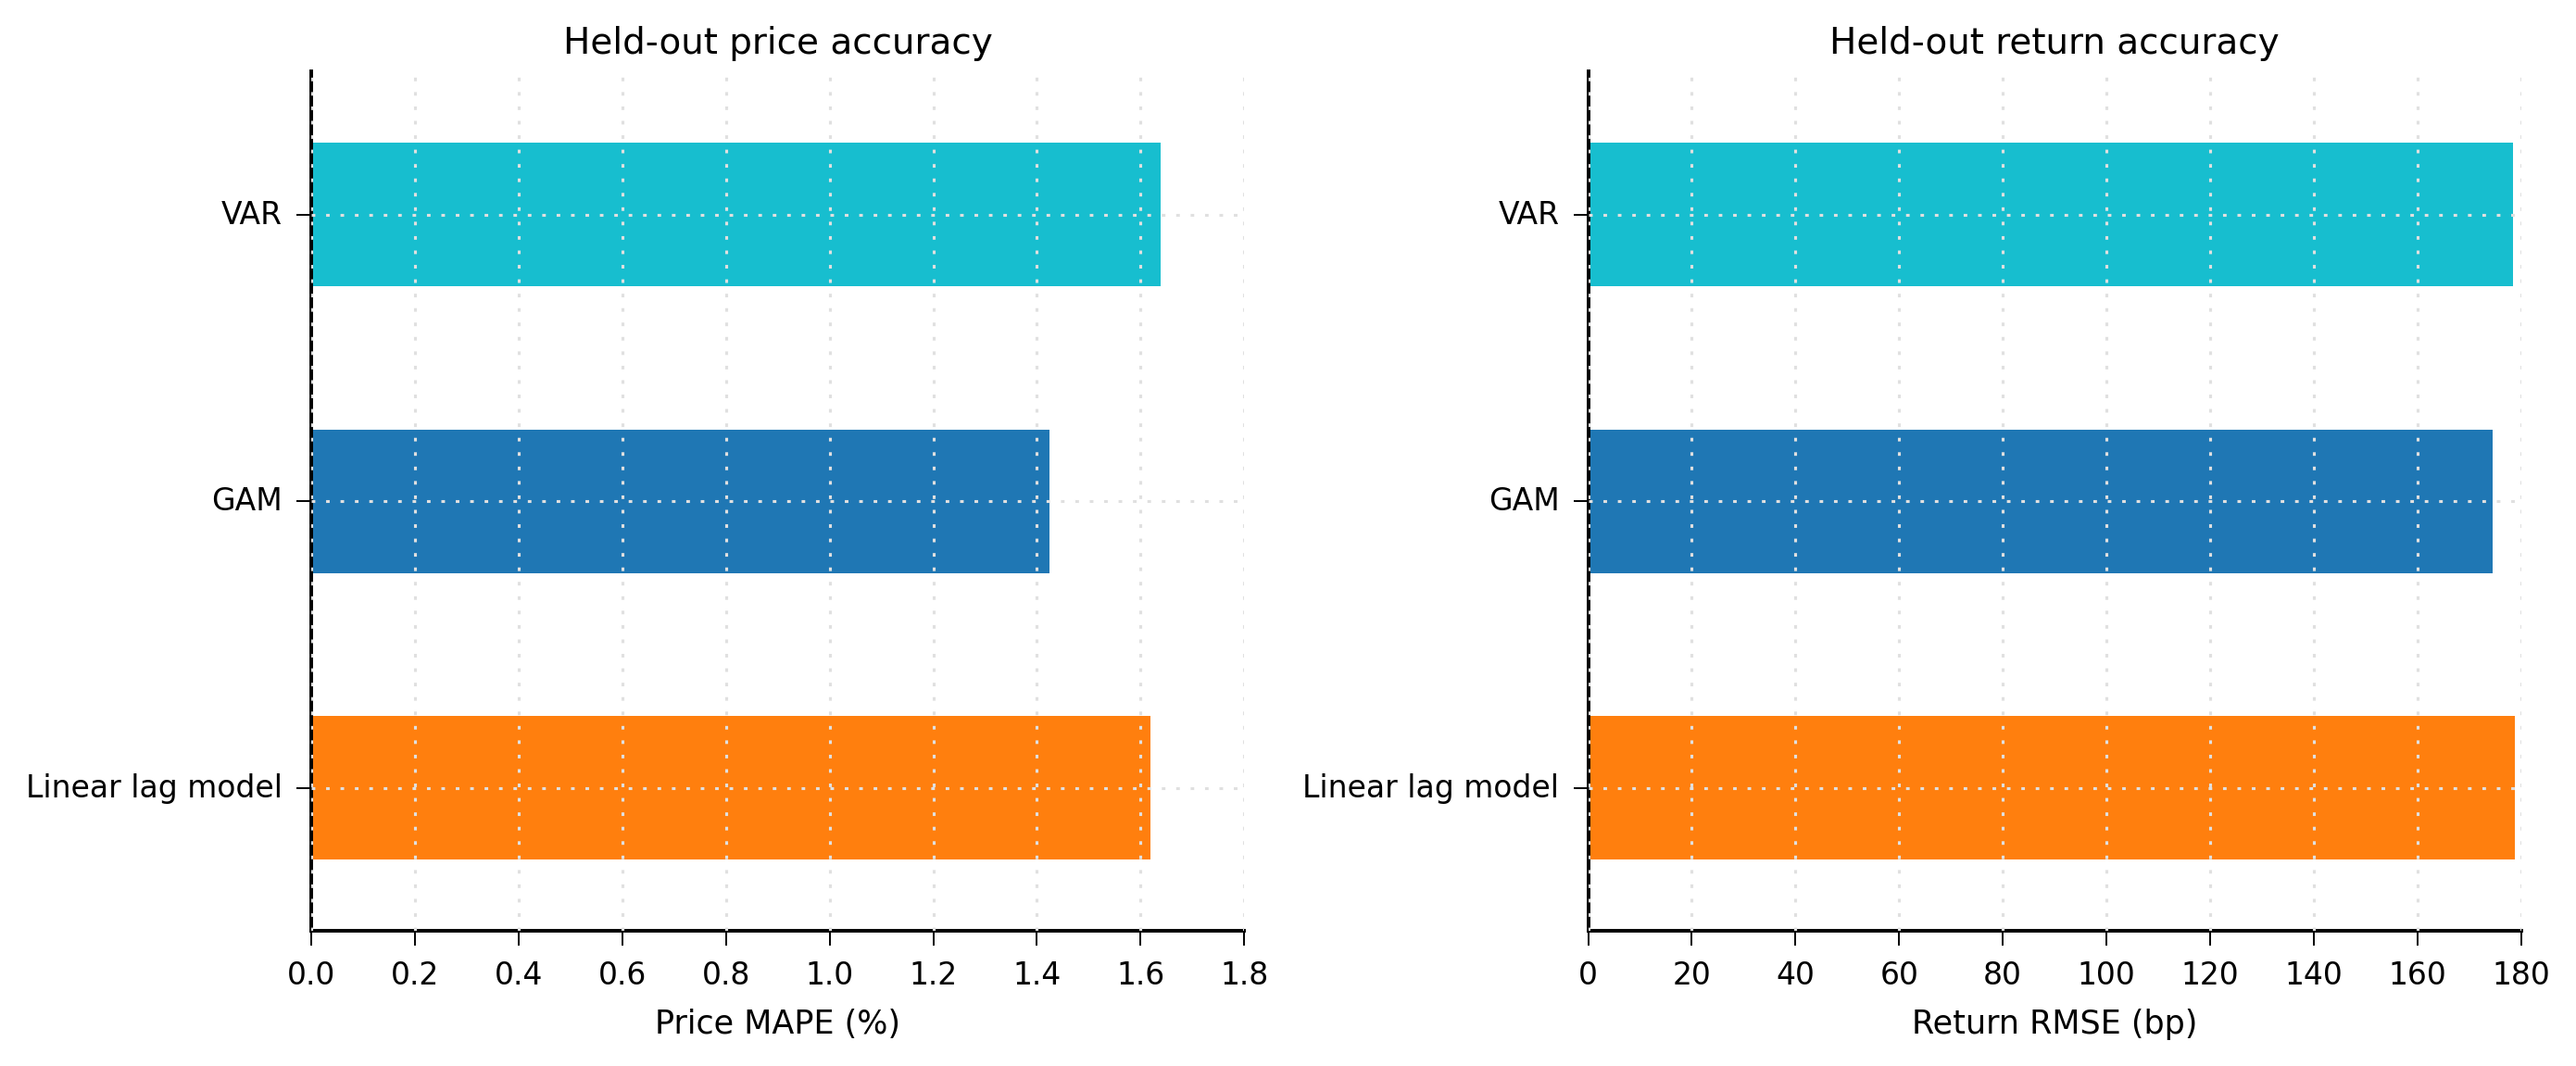

In [9]:
comparison = pd.DataFrame([linear_metrics, gam_metrics, var_metrics]).set_index("model")
display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)
comparison["price_MAPE_pct"].plot.barh(
    ax=axes[0],
    color=[MODEL_COLORS[name] for name in comparison.index],
    edgecolor="none",
)
axes[0].set_title("Held-out price accuracy")
axes[0].set_xlabel("Price MAPE (%)")
axes[0].set_ylabel("")

comparison["return_RMSE_bp"].plot.barh(
    ax=axes[1],
    color=[MODEL_COLORS[name] for name in comparison.index],
    edgecolor="none",
)
axes[1].set_title("Held-out return accuracy")
axes[1].set_xlabel("Return RMSE (bp)")
axes[1].set_ylabel("")

fig.tight_layout()
save_plot(fig, "09_model_comparison")
plt.show()

## VAR vs Stock-Only Linear Failure Case


In [ ]:
LINEAR_BAD_WINDOW_START = pd.Timestamp("2018-10-15")
LINEAR_BAD_WINDOW_END = pd.Timestamp("2018-11-12")

failure_test_returns = log_returns.loc[LINEAR_BAD_WINDOW_START:LINEAR_BAD_WINDOW_END].copy()
failure_train_returns = log_returns.loc[: failure_test_returns.index[0]].iloc[:-1].copy()
failure_test_index = failure_test_returns.index.intersection(features.index)
failure_train_index = failure_train_returns.index.intersection(features.index)

failure_linear_model = fit_ridge_model(
    features.loc[failure_train_index],
    log_returns.loc[failure_train_index, STOCK],
    lambda_=LAMBDA,
    feature_labels=FEATURE_LABELS,
)
failure_linear_pred_returns = predict_ridge_model(failure_linear_model, features.loc[failure_test_index])
failure_linear_pred_prices = to_named_series(
    returns_to_price_path(prices.loc[failure_train_returns.index[-1], STOCK], failure_linear_pred_returns),
    failure_test_index,
    "Linear lag model",
)

failure_var_pred_returns_frame, _ = rolling_var_forecast(failure_train_returns, failure_test_returns, lag=LAG)
failure_var_pred_returns_t = torch.as_tensor(
    failure_var_pred_returns_frame.loc[failure_test_index, STOCK].to_numpy(),
    dtype=torch.float64,
    device=DEVICE,
)
failure_var_pred_prices = to_named_series(
    returns_to_price_path(prices.loc[failure_train_returns.index[-1], STOCK], failure_var_pred_returns_t),
    failure_test_index,
    "VAR",
)

failure_history_prices = prices[STOCK].loc[: failure_train_returns.index[-1]]
failure_actual_prices = prices[STOCK].loc[failure_test_index]
failure_actual_returns_t = torch.as_tensor(
    failure_test_returns.loc[failure_test_index, STOCK].to_numpy(),
    dtype=torch.float64,
    device=DEVICE,
)

failure_metrics = pd.DataFrame(
    {
        "price_MAPE_pct": [
            mape_percent(failure_actual_prices, failure_linear_pred_prices),
            mape_percent(failure_actual_prices, failure_var_pred_prices),
        ],
        "return_RMSE_bp": [
            rmse_basis_points(failure_actual_returns_t, failure_linear_pred_returns),
            rmse_basis_points(failure_actual_returns_t, failure_var_pred_returns_t),
        ],
    },
    index=["Linear lag model", "VAR"],
)
display(failure_metrics.round(2))

plot_forecast(
    failure_history_prices,
    failure_actual_prices,
    {"Linear lag model": failure_linear_pred_prices, "VAR": failure_var_pred_prices},
    "Linear lag model vs VAR: rolling one-step stock forecast",
    "10_var_vs_stock_only_linear_failure",
)
plt.show()
